# Section 1: Data Processing

In this section, we:
- import the dataset,
- process the data so that it matches the format needed to train the HMM
- validate that the processed data is consistent with our expectations.

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

PATH = "sunspots_data_1957-2023.csv"

Saving sunspots_data_1957-2023.csv to sunspots_data_1957-2023.csv


In [ ]:
def load_raw_data(path=PATH):
    df = pd.read_csv(path, sep=";", low_memory=False)
    df.columns = [c.strip().replace("'", "") for c in df.columns]

    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    numeric_cols = [
        "group nr",
        "spot count",
        "weighted spot count",
        "latitude",
        "longitude",
        "manual latitude",
        "manual longitude",
        "seeing (SIDC)"
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "type" in df.columns:
        df["type"] = df["type"].astype(str).str.strip()

    df["year"] = df["date"].dt.year
    return df

def clean_morphology(df):
    valid_types = {"A", "B", "C", "D", "E", "F", "G", "H", "J"}
    out = df[df["type"].isin(valid_types)].copy()
    return out


def add_hemisphere(df):
    lat = df["latitude"].copy().fillna(df["manual latitude"])
    df = df.copy()
    df["lat_used"] = lat

    df["hemisphere"] = pd.Series(index=df.index, dtype="object")
    df.loc[lat > 0, "hemisphere"] = "N"
    df.loc[lat < 0, "hemisphere"] = "S"

    return df

def add_solar_cycle(df):
    cycle_starts = [
        ("1954-04-01", 19),
        ("1964-10-01", 20),
        ("1976-06-01", 21),
        ("1986-09-01", 22),
        ("1996-10-01", 23),
        ("2008-12-01", 24),
        ("2019-12-01", 25),
    ]
    cycle_starts = [(pd.Timestamp(d), c) for d, c in cycle_starts]

    def get_cycle(d):
        if pd.isna(d):
            return np.nan
        cycle = np.nan
        for start, c in cycle_starts:
            if d >= start:
                cycle = c
        return cycle

    df = df.copy()
    df["solar_cycle"] = df["date"].apply(get_cycle)
    return df

def add_solar_phase(df):
    cycle_start_map = {
        19: pd.Timestamp("1954-04-01"),
        20: pd.Timestamp("1964-10-01"),
        21: pd.Timestamp("1976-06-01"),
        22: pd.Timestamp("1986-09-01"),
        23: pd.Timestamp("1996-10-01"),
        24: pd.Timestamp("2008-12-01"),
        25: pd.Timestamp("2019-12-01"),
    }
    cycle_end_map = {
        19: pd.Timestamp("1964-10-01"),
        20: pd.Timestamp("1976-06-01"),
        21: pd.Timestamp("1986-09-01"),
        22: pd.Timestamp("1996-10-01"),
        23: pd.Timestamp("2008-12-01"),
        24: pd.Timestamp("2019-12-01"),
        25: pd.Timestamp("2030-01-01"),
    }

    def get_phase(row):
        c = row["solar_cycle"]
        d = row["date"]
        if pd.isna(c) or pd.isna(d):
            return np.nan
        c = int(c)
        start = cycle_start_map[c]
        end = cycle_end_map[c]
        frac = (d - start).days / max((end - start).days, 1)

        if frac < 1/3:
            return "early"
        elif frac < 2/3:
            return "mid"
        else:
            return "late"

    df = df.copy()
    df["solar_phase"] = df.apply(get_phase, axis=1)
    return df

def build_transition_table(df):
    work = df.copy()
    work = work.dropna(subset=["date", "year", "group nr.", "type"])
    work = work.sort_values(["year", "group nr.", "date"])

    grouped = work.groupby(["year", "group nr."], group_keys=False)

    work["date_t1"] = grouped["date"].shift(-1)
    work["M_t1"] = grouped["type"].shift(-1)

    transitions = work.dropna(subset=["date_t1", "M_t1"]).copy()
    transitions = transitions.rename(columns={
        "date": "date_t",
        "type": "M_t",
        "group nr.": "group_nr"
    })

    transitions = transitions[
        [
            "date_t",
            "date_t1",
            "year",
            "group_nr",
            "M_t",
            "M_t1",
            "hemisphere",
            "solar_cycle",
            "solar_phase",
            "lat_used",
        ]
    ].reset_index(drop=True)

    return transitions

def build_sequence_table(transitions):
  #drop rows with missing values ensure int indentifiers
  seq_table = transitions.dropna(subset = ["M_t", "M_t1", "solar_phase", "hemisphere", "solar_cycle"]).copy()
  seq_table["year"] = seq_table["year"].astype(int)

  #drop rows where group_nr is not strictly numeric ("294a")
  seq_table = seq_table[pd.to_numeric(seq_table["group_nr"], errors="coerce").notna()]
  seq_table["group_nr"] = seq_table["group_nr"].astype(int)

  #sort and reindex
  seq_table = seq_table.sort_values(["year", "group_nr", "date_t"]).reset_index(drop=True)

  #creating unique id for each sunspot group
  seq_table["seq_id"] = seq_table["year"].astype(str) + "_" + seq_table["group_nr"].astype(str)

  #assign timestep per sequence needed for forward and backward passes
  seq_table["step"] = seq_table.groupby("seq_id").cumcount()

  #collapse context columns into one to reduce computational complexity
  seq_table["context"] = list(zip(seq_table["solar_phase"],seq_table["hemisphere"],seq_table["solar_cycle"]))

  #track sequence length for boundaries
  seq_table["seq_length"] = seq_table.groupby("seq_id")["seq_id"].transform("size")

  #drop sequences of length 1 since no transitions to learn from
  seq_table = seq_table[seq_table["seq_length"] > 1]

  #track time between transitons for potential hyperparameter search (1 day between observation vs 10 days can be treated differently)
  seq_table["transition_gap"] = (seq_table["date_t1"] - seq_table["date_t"]).dt.days

  #drop gaps of more than 1 day for continuity
  #NOTE: HYPERPARAMTER SEARCH NEEDED FOR >1 or >2
  bad_seq_id = seq_table[seq_table["transition_gap"] > 2]["seq_id"].unique()
  seq_table = seq_table[~seq_table["seq_id"].isin(bad_seq_id)]

  #recompute step and sequence length after dropping
  seq_table = seq_table.sort_values(["seq_id", "date_t"]).reset_index(drop=True)
  seq_table["step"] = seq_table.groupby("seq_id").cumcount()
  seq_table["seq_length"] = seq_table.groupby("seq_id")["seq_id"].transform("size")


  #formatting
  seq_table = seq_table[
        [
            "seq_id",
            "step",
            "seq_length",
            "date_t",
            "date_t1",
            "transition_gap",
            "M_t",
            "M_t1",
            "context",
            "hemisphere",
            "solar_cycle",
            "solar_phase",
        ]
    ].reset_index(drop=True)

  return seq_table



In [ ]:
df = load_raw_data()
df = clean_morphology(df)
df = add_hemisphere(df)
df = add_solar_cycle(df)
df = add_solar_phase(df)
transitions = build_transition_table(df)
seq_table = build_sequence_table(transitions)

print("Transitions used by model:", len(seq_table))
print(seq_table.head())

Transitions used by model: 64369
     seq_id  step  seq_length     date_t    date_t1  transition_gap M_t M_t1  \
0  1957_305     0           2 1957-06-09 1957-06-11               2   B    H   
1  1957_305     1           2 1957-06-11 1957-06-13               2   H    H   
2  1957_306     0           4 1957-06-09 1957-06-11               2   A    A   
3  1957_306     1           4 1957-06-11 1957-06-13               2   A    A   
4  1957_306     2           4 1957-06-13 1957-06-14               1   A    A   

          context hemisphere  solar_cycle solar_phase  
0  (early, S, 19)          S           19       early  
1  (early, S, 19)          S           19       early  
2  (early, S, 19)          S           19       early  
3  (early, S, 19)          S           19       early  
4  (early, S, 19)          S           19       early  


###Distributions

15
count    64369.000000
mean         7.773913
std          3.101639
min          2.000000
25%          5.000000
50%          8.000000
75%         10.000000
max         15.000000
Name: seq_length, dtype: float64


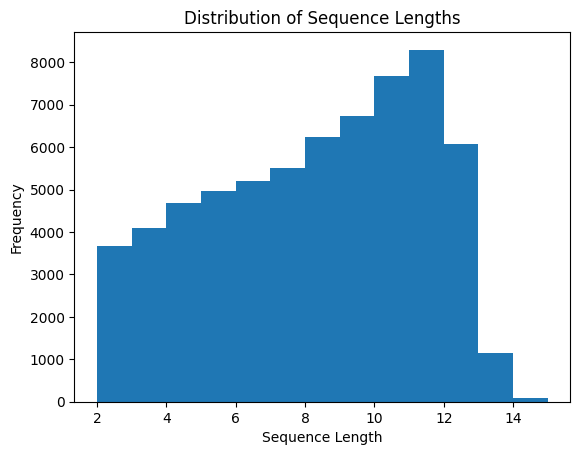

In [ ]:
#looking at distribution of sequence length for
print(seq_table["seq_length"].max())
print(seq_table["seq_length"].describe())

import matplotlib.pyplot as plt

data = seq_table["seq_length"]

plt.figure()
plt.hist(data, bins=13)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sequence Lengths")
plt.show()

###Distribution for transition gaps

count    64369.000000
mean         1.076776
std          0.268041
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: transition_gap, dtype: float64


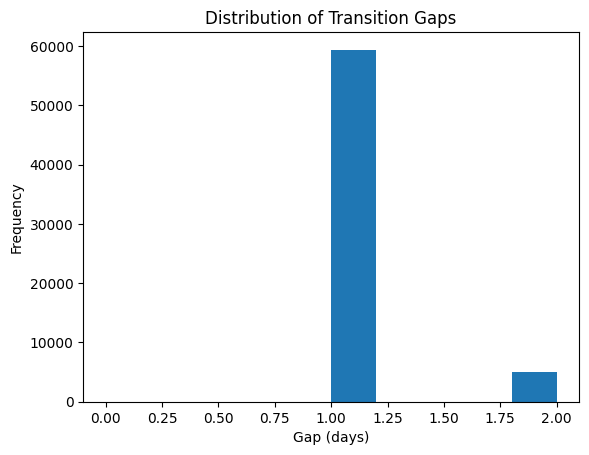

In [ ]:
print(seq_table["transition_gap"].describe())
data = seq_table["transition_gap"]

plt.figure()
plt.hist(data, bins=10)
plt.xlabel("Gap (days)")
plt.ylabel("Frequency")
plt.title("Distribution of Transition Gaps")
plt.show()

In [ ]:
seq_table["M_t"].value_counts(normalize=True)

,proportion
M_t,
C,0.233622
D,0.196166
J,0.193991
B,0.159378
A,0.113875
E,0.051997
H,0.027156
G,0.013951
F,0.009865


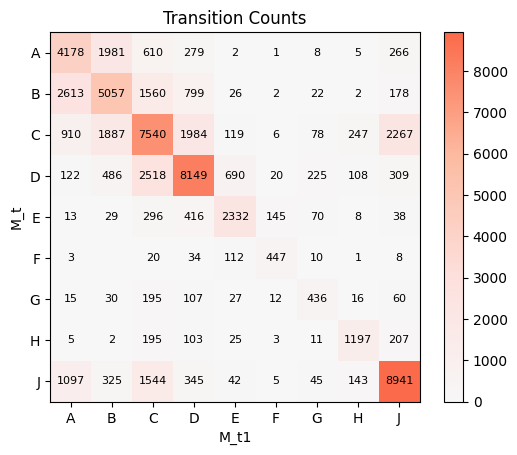

In [ ]:
transition_counts = pd.crosstab(
    seq_table["M_t"],
    seq_table["M_t1"]
)

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# pastel gray → red
cmap = LinearSegmentedColormap.from_list(
    "pastel_red",
    ["#f7f7f7", "#fde0dd", "#fcbba1", "#fb6a4a"]
)

plt.figure()
plt.imshow(transition_counts.values, cmap=cmap)

plt.xticks(range(len(transition_counts.columns)), transition_counts.columns)
plt.yticks(range(len(transition_counts.index)), transition_counts.index)

plt.xlabel("M_t1")
plt.ylabel("M_t")
plt.title("Transition Counts")

# annotate
for i in range(transition_counts.shape[0]):
    for j in range(transition_counts.shape[1]):
        val = transition_counts.values[i, j]
        if val > 0:
            plt.text(j, i, str(val), ha="center", va="center", fontsize=8)

plt.colorbar()
plt.show()

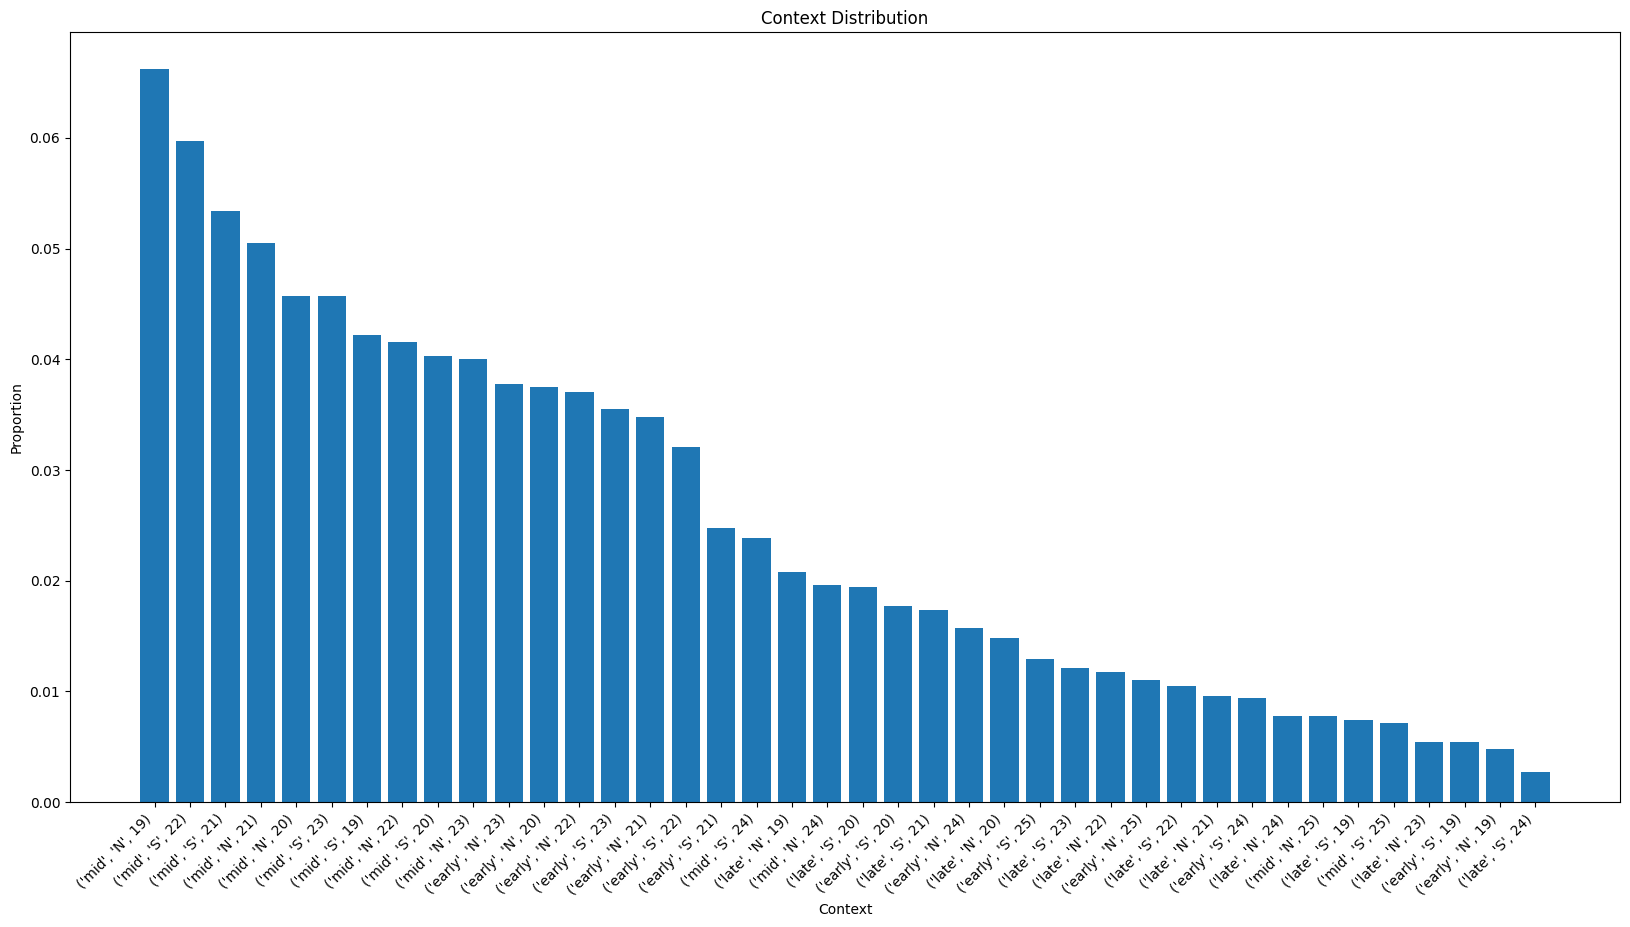

In [ ]:
import matplotlib.pyplot as plt

data = seq_table["context"].value_counts(normalize=True)

plt.figure(figsize = (20,10))
plt.bar(range(len(data)), data.values)
plt.xticks(range(len(data)), [str(x) for x in data.index], rotation=45, ha='right')
plt.ylabel("Proportion")
plt.xlabel("Context")
plt.title("Context Distribution")
plt.show()

#Section 2: Sequence Packaging

In [ ]:
def encode_sequence(seq_table):

  #union for full coverage collecting unique states
  morphology = sorted(set(seq_table["M_t"]).union(set(seq_table["M_t1"])))

  #morphology -> ID
  morphology_to_id = {morphology: i for i, morphology in enumerate(morphology)}

  #ID -> morphology
  id_to_morphology = {i: morphology for morphology, i in morphology_to_id.items()}

  contexts = sorted(seq_table["context"].unique())
  context_to_id = {context: i for i, context in enumerate(contexts)}
  id_to_context = {i: context for context, i in context_to_id.items()}

  return morphology_to_id, id_to_morphology, context_to_id, id_to_context




In [ ]:
morphology_to_id, id_to_morphology, context_to_id, id_to_context = encode_sequence(seq_table)

print("Morphology mapping:")
print(morphology_to_id)

print("\nFirst few context mappings:")
for i, (context, id) in enumerate(context_to_id.items()):
    print(context, "->", id)
    if i >= 3:
        break

Morphology mapping:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'J': 8}

First few context mappings:
('early', 'N', 19) -> 0
('early', 'N', 20) -> 1
('early', 'N', 21) -> 2
('early', 'N', 22) -> 3


In [ ]:
def encode_sequence_table(seq_table, morphology_to_id, context_to_id):
    encoded = seq_table.copy()

    encoded["m_curr_id"] = encoded["M_t"].map(morphology_to_id).astype(int)
    encoded["m_next_id"] = encoded["M_t1"].map(morphology_to_id).astype(int)
    encoded["context_id"] = encoded["context"].map(context_to_id).astype(int)

    return encoded

In [ ]:
seq_table_encoded = encode_sequence_table(seq_table,morphology_to_id=morphology_to_id,context_to_id=context_to_id)

print(seq_table_encoded.head())

     seq_id  step  seq_length     date_t    date_t1  transition_gap M_t M_t1  \
0  1957_305     0           2 1957-06-09 1957-06-11               2   B    H   
1  1957_305     1           2 1957-06-11 1957-06-13               2   H    H   
2  1957_306     0           4 1957-06-09 1957-06-11               2   A    A   
3  1957_306     1           4 1957-06-11 1957-06-13               2   A    A   
4  1957_306     2           4 1957-06-13 1957-06-14               1   A    A   

          context hemisphere  solar_cycle solar_phase  m_curr_id  m_next_id  \
0  (early, S, 19)          S           19       early          1          7   
1  (early, S, 19)          S           19       early          7          7   
2  (early, S, 19)          S           19       early          0          0   
3  (early, S, 19)          S           19       early          0          0   
4  (early, S, 19)          S           19       early          0          0   

   context_id  
0           7  
1           

In [ ]:
def split(seq_table, val=0.15, test=0.15, seed=1):

    rng = np.random.default_rng(seed)
    seq_ids = np.array(sorted(seq_table["seq_id"].unique()))
    shuffled_seq_ids = rng.permutation(seq_ids)

    n_total = len(shuffled_seq_ids)
    n_test = int(np.floor(test * n_total))
    n_val = int(np.floor(val * n_total))

    test_seq_ids = set(shuffled_seq_ids[:n_test])
    val_seq_ids = set(shuffled_seq_ids[n_test:n_test + n_val])
    train_seq_ids = set(shuffled_seq_ids[n_test + n_val:])

    return train_seq_ids, val_seq_ids, test_seq_ids

In [ ]:
train_seq_ids, val_seq_ids, test_seq_ids = split(seq_table_encoded,val=0.15,test=0.15,seed=1)

#create independent tables for each split
train_seq_table = seq_table_encoded[seq_table_encoded["seq_id"].isin(train_seq_ids)].copy()
val_seq_table = seq_table_encoded[seq_table_encoded["seq_id"].isin(val_seq_ids)].copy()
test_seq_table = seq_table_encoded[seq_table_encoded["seq_id"].isin(test_seq_ids)].copy()

print("Train sequences:", len(train_seq_ids))
print("Validation sequences:", len(val_seq_ids))
print("Test sequences:", len(test_seq_ids))

print("\nTrain transitions:", len(train_seq_table))
print("Validation transitions:", len(val_seq_table))
print("Test transitions:", len(test_seq_table))


Train sequences: 7472
Validation sequences: 1600
Test sequences: 1600

Train transitions: 44992
Validation transitions: 9707
Test transitions: 9670


In [ ]:
def summarize_split(name, split_seq_table):
    print(f"{name} summary")
    print("Rows:", len(split_seq_table))
    print("Sequences:", split_seq_table["seq_id"].nunique())
    print("Sequence length summary:")
    print(split_seq_table.groupby("seq_id").size().describe())

    context_parts = split_seq_table["context"].apply(pd.Series)
    context_parts.columns = ["solar_phase", "hemisphere", "solar_cycle"]

    print("\nSolar phase proportions:")
    print(context_parts["solar_phase"].value_counts(normalize=True).sort_index())

    print("\nHemisphere proportions:")
    print(context_parts["hemisphere"].value_counts(normalize=True).sort_index())

    print("\nSolar cycle proportions:")
    print(context_parts["solar_cycle"].value_counts(normalize=True).sort_index())

    print("\nTop 10 contexts:")
    print(split_seq_table["context"].value_counts().head(10))

    print("\n" + "=" * 60 + "\n")

In [ ]:
def split_summary_frame(split_seq_table, split_name):
    # unpack context tuple into separate columns
    context_parts = split_seq_table["context"].apply(pd.Series)
    context_parts.columns = ["solar_phase", "hemisphere", "solar_cycle"]

    seq_lengths = split_seq_table.groupby("seq_id").size()

    return {
        "name": split_name,
        "rows": len(split_seq_table),
        "sequences": split_seq_table["seq_id"].nunique(),
        "seq_lengths": seq_lengths,
        "solar_phase_props": context_parts["solar_phase"].value_counts(normalize=True).sort_index(),
        "hemisphere_props": context_parts["hemisphere"].value_counts(normalize=True).sort_index(),
        "solar_cycle_props": context_parts["solar_cycle"].value_counts(normalize=True).sort_index(),
        "context_tuple_props": split_seq_table["context_id"].value_counts(normalize=True),
    }



def compare_sequence_lengths(*split_summaries):
    plt.figure(figsize=(8, 5))
    for s in split_summaries:
        s["seq_lengths"].plot(kind="kde", label=s["name"])
    plt.title("Sequence Length Distribution")
    plt.xlabel("Sequence Length")
    plt.legend()
    plt.show()


def compare_categorical_distribution(split_summaries, key, title):
    all_index = sorted(set().union(*[set(s[key].index) for s in split_summaries]))
    df = pd.DataFrame(
        {s["name"]: s[key].reindex(all_index, fill_value=0) for s in split_summaries},
        index=all_index
    )

    df.plot(kind="bar", figsize=(9, 5))
    plt.title(title)
    plt.ylabel("Proportion")
    plt.xlabel("")
    plt.xticks(rotation=0)
    plt.legend(title="Split")
    plt.show()




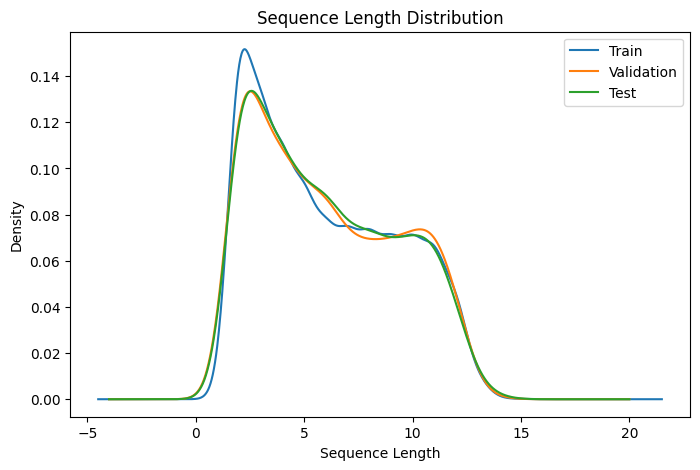

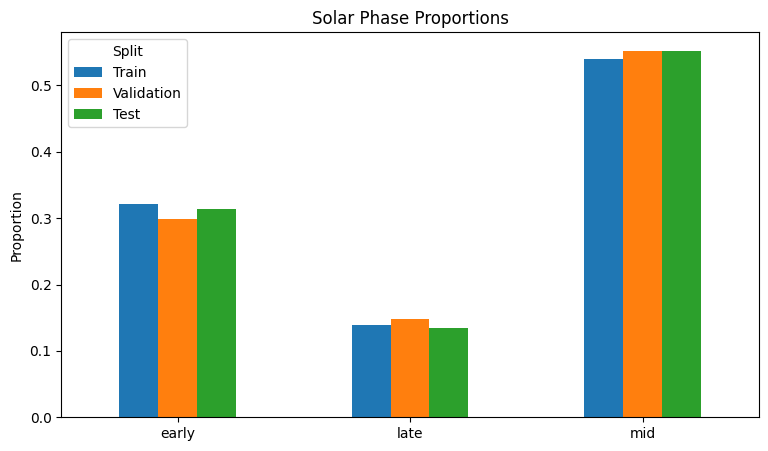

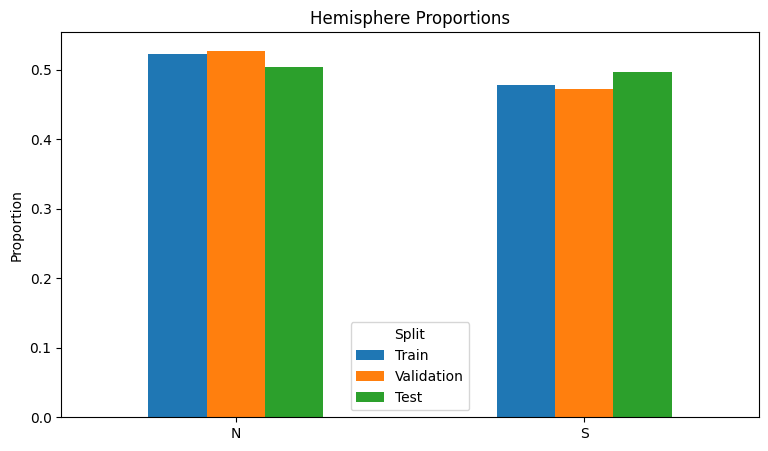

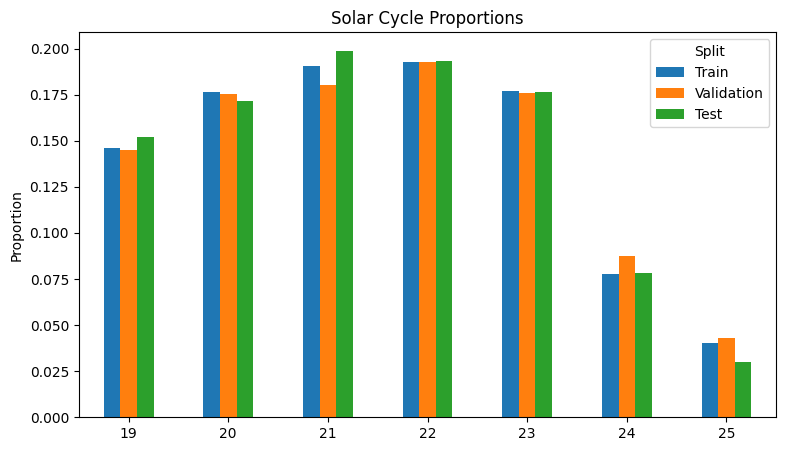

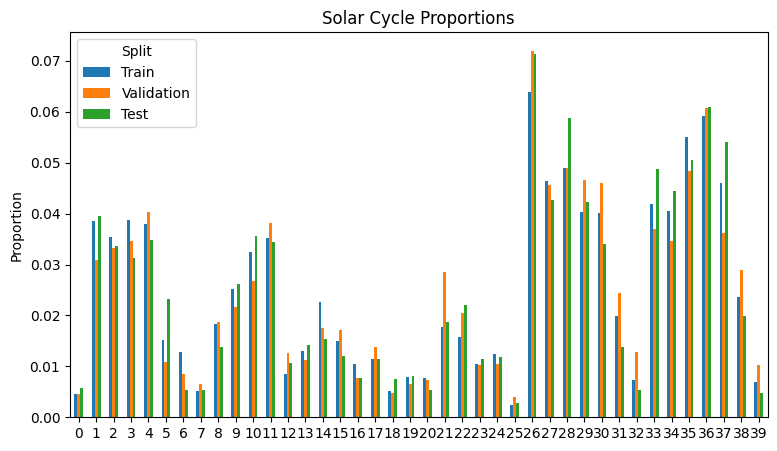

In [ ]:
train_summary = split_summary_frame(train_seq_table, "Train")
val_summary = split_summary_frame(val_seq_table, "Validation")
test_summary = split_summary_frame(test_seq_table, "Test")

compare_sequence_lengths(train_summary, val_summary, test_summary)

compare_categorical_distribution(
    [train_summary, val_summary, test_summary],
    "solar_phase_props",
    "Solar Phase Proportions"
)

compare_categorical_distribution(
    [train_summary, val_summary, test_summary],
    "hemisphere_props",
    "Hemisphere Proportions"
)

compare_categorical_distribution(
    [train_summary, val_summary, test_summary],
    "solar_cycle_props",
    "Solar Cycle Proportions"
)

compare_categorical_distribution(
    [train_summary, val_summary, test_summary],
    "context_tuple_props",
    "Solar Cycle Proportions"
)


###Convert splits into sequence objects

In [ ]:
def table_to_objects(encoded_seq_table):
    sequence_objects = []

    #construct smaller tables by group and sort by step size
    for seq_id, group in encoded_seq_table.groupby("seq_id", sort=True):
        group = group.sort_values("step").reset_index(drop=True)

        sequence_object = {
            "seq_id": seq_id,
            "m_curr": group["m_curr_id"].to_numpy(),
            "m_next": group["m_next_id"].to_numpy(),
            "context": group["context_id"].to_numpy(),
            "length": len(group),
            "steps": group["step"].to_numpy(dtype=int),
            "M_t_label": group["M_t"].tolist(),
            "M_t1_label": group["M_t1"].tolist(),
            "context_label": group["context"].tolist(),
            "date_t": group["date_t"].tolist(),
            "date_t1": group["date_t1"].tolist(),
        }

        sequence_objects.append(sequence_object)

    return sequence_objects

In [ ]:
train_sequences = table_to_objects(train_seq_table)
val_sequences = table_to_objects(val_seq_table)
test_sequences = table_to_objects(test_seq_table)

print("Train sequence objects:", len(train_sequences))
print("Validation sequence objects:", len(val_sequences))
print("Test sequence objects:", len(test_sequences))

#validate by inspecting example
example = train_sequences[1]

print("\nExample seq_id:")
print(example["seq_id"])

print("\nLength:")
print(example["length"])

print("\nm_curr:")
print(example["m_curr"])

print("\nm_next:")
print(example["m_next"])

print("\ncontext:")
print(example["context"])

print("\nM_t_label:")
print(example["M_t_label"])

print("\nM_t1_label:")
print(example["M_t1_label"])

print("\ncontext_label:")
print(example["context_label"])

Train sequence objects: 7472
Validation sequence objects: 1600
Test sequence objects: 1600

Example seq_id:
1957_306

Length:
4

m_curr:
[0 0 0 0]

m_next:
[0 0 0 1]

context:
[7 7 7 7]

M_t_label:
['A', 'A', 'A', 'A']

M_t1_label:
['A', 'A', 'A', 'B']

context_label:
[('early', 'S', 19), ('early', 'S', 19), ('early', 'S', 19), ('early', 'S', 19)]


###Final Validations and defining model dimensions to pass of to downstream models

In [ ]:
#needed to define structure shapes
S = len(morphology_to_id) #number of morphological states
R = len(context_to_id) #number of context combinations

print("Number of morphology states S:", S)
print("Number of context combinations R:", R)

print("\nMorphology mapping:")
print(morphology_to_id)

print("\nFirst 5 context mappings:")
for i in range(min(5, R)):
    print(i, "->", id_to_context[i])

print("\nTotal transitions")
print("Train:", sum(seq["length"] for seq in train_sequences))
print("Validation:", sum(seq["length"] for seq in val_sequences))
print("Test:", sum(seq["length"] for seq in test_sequences))

Number of morphology states S: 9
Number of context combinations R: 40

Morphology mapping:
{'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'J': 8}

First 5 context mappings:
0 -> ('early', 'N', 19)
1 -> ('early', 'N', 20)
2 -> ('early', 'N', 21)
3 -> ('early', 'N', 22)
4 -> ('early', 'N', 23)

Total transitions
Train: 44992
Validation: 9707
Test: 9670


#Section 3: Base Model

In [ ]:
def fit_base_model(train_sequences,S,R,smoothing=1.0):
  #counts[c,i,j] how many times we see transitions i -> j under context c
  counts = np.full((R,S,S),smoothing,dtype=float) #float to account for smoothing

  #iterate over sequences
  for seq in train_sequences:
    m_curr = seq["m_curr"]
    m_next = seq["m_next"]
    context = seq["context"]

    #iterate over steps in sequence
    for step in range(seq["length"]):
      counts[context[step],m_curr[step],m_next[step]] += 1.0

  probabilities = counts / counts.sum(axis=2,keepdims=True) #ensures (c,i,j) and probability of context with curr sums to 1.

  return probabilities

def base_loglikelihood(sequence,probabilities):

  m_curr = sequence["m_curr"]
  m_next = sequence["m_next"]
  context = sequence["context"]

  #NumPy loops implicity
  p = probabilities[context,m_curr,m_next] #p = probability of transition under context
  p = np.clip(p,1e-10,None) #prevents log(0)

  return np.log(p).sum()

def base_performance(sequences, probabilities):
  loglikelihood = 0.0
  total_transitions = 0
  total_correct = 0

  for sequence in sequences:
    m_curr = sequence["m_curr"]
    m_next = sequence["m_next"]
    context = sequence["context"]

    loglikelihood += base_loglikelihood(sequence,probabilities)
    total_transitions += sequence["length"] #length defined as number of timesteps (transitions)

    distribution_at_t = probabilities[context,m_curr,:] # shape (timesteps,number of states)
    prediction = np.argmax(distribution_at_t,axis=1) #apply at timesteps
    total_correct += np.sum(prediction == m_next)


  return {
      "total log-likelihood": loglikelihood,
      "average log-likelihood per transition": loglikelihood /total_transitions,
      "perplexity": np.exp(-loglikelihood / total_transitions),
      "accuracy": total_correct / total_transitions ,
      "number of sequences": len(sequences),
      "number of transitions": total_transitions
  }

def print_baseline_results(name, results):
    print(f"\n{name}")
    print(f"Sequences:                {results['number of sequences']}")
    print(f"Transitions:              {results['number of transitions']}")
    print(f"Total log-likelihood:     {results['total log-likelihood']:.2f}")
    print(f"Average log-likelihood per transition:  {results['average log-likelihood per transition']:.6f}")
    print(f"Perplexity:               {results['perplexity']:.3f}")
    print(f"Accuracy:                 {results['accuracy']:.4f}")




In [ ]:
base_probabilities = fit_base_model(train_sequences, S=S, R=R, smoothing=1.0)

train_results = base_performance(train_sequences, base_probabilities)
val_results = base_performance(val_sequences, base_probabilities)
test_results = base_performance(test_sequences, base_probabilities)

print_baseline_results("TRAIN", train_results)
print_baseline_results("VALIDATION", val_results)
print_baseline_results("TEST", test_results)


TRAIN
Sequences:                7472
Transitions:              44992
Total log-likelihood:     -53713.60
Average log-likelihood per transition:  -1.193848
Perplexity:               3.300
Accuracy:                 0.5944

VALIDATION
Sequences:                1600
Transitions:              9707
Total log-likelihood:     -11881.61
Average log-likelihood per transition:  -1.224025
Perplexity:               3.401
Accuracy:                 0.5925

TEST
Sequences:                1600
Transitions:              9670
Total log-likelihood:     -11817.80
Average log-likelihood per transition:  -1.222110
Perplexity:               3.394
Accuracy:                 0.5896


# Section 4: Hidden-State DBN


In [ ]:
import numpy as np

def initialize_hidden_model(S, R, K, seed=1, smoothing=1.0):
    rng = np.random.default_rng(seed)

    pi = rng.random((R, K)) + smoothing
    pi = pi / pi.sum(axis=1, keepdims=True)

    A = rng.random((R, K, K)) + smoothing
    A = A / A.sum(axis=2, keepdims=True)

    B = rng.random((S, K, S)) + smoothing
    B = B / B.sum(axis=2, keepdims=True)

    return pi, A, B

In [ ]:
S = len(morphology_to_id)
R = len(context_to_id)

print("S =", S)
print("R =", R)

K = 2
pi, A, B = initialize_hidden_model(S=S, R=R, K=K, seed=1, smoothing=1.0)

print("pi shape:", pi.shape)
print("A shape:", A.shape)
print("B shape:", B.shape)

S = 9
R = 40
pi shape: (40, 2)
A shape: (40, 2, 2)
B shape: (9, 2, 9)


In [ ]:
def emission_likelihoods(sequence, B):
    m_curr = sequence["m_curr"]
    m_next = sequence["m_next"]
    T = sequence["length"]
    K = B.shape[1]

    E = np.zeros((T, K), dtype=float)

    for t in range(T):
        for z in range(K):
            E[t, z] = B[m_curr[t], z, m_next[t]]

    return E

In [ ]:
example_seq = train_sequences[0]
E = emission_likelihoods(example_seq, B)

print("Sequence ID:", example_seq["seq_id"])
print("Emission likelihood shape:", E.shape)
print(E[:5])

Sequence ID: 1957_305
Emission likelihood shape: (2, 2)
[[0.08634271 0.10677154]
 [0.10546928 0.11975484]]


In [ ]:
print("pi row sums:", np.round(pi.sum(axis=1)[:5], 6))
print("A row sums:", np.round(A.sum(axis=2)[0], 6))
print("B row sums:", np.round(B.sum(axis=2)[0], 6))

pi row sums: [1. 1. 1. 1. 1.]
A row sums: [1. 1.]
B row sums: [1. 1.]


Created random initial guesses for the hidden-state model parameters and normalized them so each relevant slice is a proper probability distribution

## Forward pass


In [ ]:
def forward_pass(sequence, pi, A, B):
    m_curr = sequence["m_curr"]
    m_next = sequence["m_next"]
    context = sequence["context"]
    T = sequence["length"]
    K = pi.shape[1]

    alpha = np.zeros((T, K), dtype=float)
    scales = np.zeros(T, dtype=float)

    # t = 0
    emission_0 = B[m_curr[0], :, m_next[0]]
    alpha[0] = pi[context[0]] * emission_0
    scales[0] = alpha[0].sum()
    alpha[0] /= scales[0]

    # t = 1, ..., T-1
    for t in range(1, T):
        emission_t = B[m_curr[t], :, m_next[t]]
        alpha[t] = (alpha[t - 1] @ A[context[t]]) * emission_t
        scales[t] = alpha[t].sum()
        alpha[t] /= scales[t]

    loglikelihood = np.log(scales).sum()
    return alpha, scales, loglikelihood

In [ ]:
example_seq = train_sequences[0]

alpha, scales, loglikelihood = forward_pass(example_seq, pi, A, B)

print("Sequence ID:", example_seq["seq_id"])
print("Alpha shape:", alpha.shape)
print("Scales shape:", scales.shape)
print("Log-likelihood:", loglikelihood)

print("\nFirst few alpha rows:")
print(alpha[:5])

print("\nFirst few scales:")
print(scales[:5])

Sequence ID: 1957_305
Alpha shape: (2, 2)
Scales shape: (2,)
Log-likelihood: -4.524812216497845

First few alpha rows:
[[0.42030505 0.57969495]
 [0.54034728 0.45965272]]

First few scales:
[0.09711405 0.11158787]


In [ ]:
print("Alpha row sums:")
print(alpha.sum(axis=1))
print("All finite?", np.isfinite(alpha).all(), np.isfinite(scales).all(), np.isfinite(loglikelihood))

Alpha row sums:
[1. 1.]
All finite? True True True


## Backward Pass

In [ ]:
def backward_pass(sequence, A, B, scales):
    m_curr = sequence["m_curr"]
    m_next = sequence["m_next"]
    context = sequence["context"]
    T = sequence["length"]
    K = A.shape[1]

    beta = np.zeros((T, K), dtype=float)

    # final step
    beta[T - 1] = 1.0

    # backward recursion
    for t in range(T - 2, -1, -1):
        emission_next = B[m_curr[t + 1], :, m_next[t + 1]]
        beta[t] = A[context[t + 1]] @ (emission_next * beta[t + 1])
        beta[t] /= scales[t + 1]

    return beta

In [ ]:
beta = backward_pass(example_seq, A, B, scales)

print("Beta shape:", beta.shape)
print(beta)

print("\nAll finite?", np.isfinite(beta).all())

Beta shape: (2, 2)
[[0.9943004  1.00413247]
 [1.         1.        ]]

All finite? True


## E-Step

In [ ]:
def compute_gamma_xi(sequence, alpha, beta, A, B):
    m_curr = sequence["m_curr"]
    m_next = sequence["m_next"]
    context = sequence["context"]
    T = sequence["length"]
    K = alpha.shape[1]

    gamma = alpha * beta
    gamma = gamma / gamma.sum(axis=1, keepdims=True)

    xi = np.zeros((T - 1, K, K), dtype=float)

    for t in range(T - 1):
        emission_next = B[m_curr[t + 1], :, m_next[t + 1]]

        numer = (
            alpha[t][:, None]
            * A[context[t + 1]]
            * (emission_next * beta[t + 1])[None, :]
        )

        denom = numer.sum()
        xi[t] = numer / denom

    return gamma, xi

In [ ]:
gamma, xi = compute_gamma_xi(example_seq, alpha, beta, A, B)

print("Gamma shape:", gamma.shape)
print(gamma)

print("\nXi shape:", xi.shape)
print(xi)

print("\nGamma row sums:")
print(gamma.sum(axis=1))

print("\nXi row sums:")
print([xi[t].sum() for t in range(xi.shape[0])])

Gamma shape: (2, 2)
[[0.41790948 0.58209052]
 [0.54034728 0.45965272]]

Xi shape: (1, 2, 2)
[[[0.24479701 0.17311247]
  [0.29555027 0.28654025]]]

Gamma row sums:
[1. 1.]

Xi row sums:
[np.float64(1.0)]


## M-Step

In [ ]:
def expected_counts(train_sequences, pi, A, B, R, S, K):
    pi_counts = np.zeros((R, K), dtype=float)
    A_counts = np.zeros((R, K, K), dtype=float)
    B_counts = np.zeros((S, K, S), dtype=float)

    total_loglikelihood = 0.0

    for sequence in train_sequences:
        alpha, scales, loglikelihood = forward_pass(sequence, pi, A, B)
        beta = backward_pass(sequence, A, B, scales)
        gamma, xi = compute_gamma_xi(sequence, alpha, beta, A, B)

        total_loglikelihood += loglikelihood

        m_curr = sequence["m_curr"]
        m_next = sequence["m_next"]
        context = sequence["context"]
        T = sequence["length"]

        # initial-state counts
        pi_counts[context[0]] += gamma[0]

        # transition counts
        for t in range(T - 1):
            A_counts[context[t + 1]] += xi[t]

        # emission counts
        for t in range(T):
            B_counts[m_curr[t], :, m_next[t]] += gamma[t]

    return pi_counts, A_counts, B_counts, total_loglikelihood

In [ ]:
pi_counts, A_counts, B_counts, total_loglikelihood = expected_counts(
    train_sequences, pi, A, B, R, S, K
)

print("pi_counts shape:", pi_counts.shape)
print("A_counts shape:", A_counts.shape)
print("B_counts shape:", B_counts.shape)
print("Total train log-likelihood:", total_loglikelihood)

pi_counts shape: (40, 2)
A_counts shape: (40, 2, 2)
B_counts shape: (9, 2, 9)
Total train log-likelihood: -96045.57688528571


In [ ]:
def m_step_update(pi_counts, A_counts, B_counts, smoothing=1.0):
    pi_new = pi_counts + smoothing
    pi_new = pi_new / pi_new.sum(axis=1, keepdims=True)

    A_new = A_counts + smoothing
    A_new = A_new / A_new.sum(axis=2, keepdims=True)

    B_new = B_counts + smoothing
    B_new = B_new / B_new.sum(axis=2, keepdims=True)

    return pi_new, A_new, B_new

In [ ]:
pi_new, A_new, B_new = m_step_update(pi_counts, A_counts, B_counts, smoothing=1.0)

print("pi row sums:", np.round(pi_new.sum(axis=1)[:5], 6))
print("A row sums:", np.round(A_new.sum(axis=2)[0], 6))
print("B row sums:", np.round(B_new.sum(axis=2)[0], 6))

pi row sums: [1. 1. 1. 1. 1.]
A row sums: [1. 1.]
B row sums: [1. 1.]


In [ ]:
def em_iteration(train_sequences, pi, A, B, R, S, K, smoothing=1.0):
    pi_counts, A_counts, B_counts, total_loglikelihood = expected_counts(
        train_sequences, pi, A, B, R, S, K
    )

    pi_new, A_new, B_new = m_step_update(
        pi_counts, A_counts, B_counts, smoothing=smoothing
    )

    return pi_new, A_new, B_new, total_loglikelihood

In [ ]:
pi_1, A_1, B_1, train_ll_0 = em_iteration(
    train_sequences, pi, A, B, R, S, K, smoothing=1.0
)

print("Train log-likelihood from current parameters:", train_ll_0)
print("Updated shapes:", pi_1.shape, A_1.shape, B_1.shape)

Train log-likelihood from current parameters: -96045.57688528571
Updated shapes: (40, 2) (40, 2, 2) (9, 2, 9)


In [ ]:
def hidden_sequence_loglikelihood(sequence, pi, A, B):
    _, _, loglikelihood = forward_pass(sequence, pi, A, B)
    return loglikelihood

def hidden_performance(sequences, pi, A, B):
    total_loglikelihood = 0.0
    total_transitions = 0
    total_correct = 0

    K_local = B.shape[1]
    S_local = B.shape[2]

    for sequence in sequences:
        alpha, scales, loglikelihood = forward_pass(sequence, pi, A, B)
        beta = backward_pass(sequence, A, B, scales)
        gamma, _ = compute_gamma_xi(sequence, alpha, beta, A, B)

        total_loglikelihood += loglikelihood
        total_transitions += sequence["length"]

        m_curr = sequence["m_curr"]

        preds = []
        for t in range(sequence["length"]):
            pred_dist = np.zeros(S_local, dtype=float)
            for z in range(K_local):
                pred_dist += gamma[t, z] * B[m_curr[t], z, :]
            preds.append(np.argmax(pred_dist))

        preds = np.array(preds)
        total_correct += np.sum(preds == sequence["m_next"])

    return {
        "total log-likelihood": total_loglikelihood,
        "average log-likelihood per transition": total_loglikelihood / total_transitions,
        "perplexity": np.exp(-total_loglikelihood / total_transitions),
        "accuracy": total_correct / total_transitions,
        "number of sequences": len(sequences),
        "number of transitions": total_transitions,
    }

In [ ]:
hidden_train_results = hidden_performance(train_sequences, pi_1, A_1, B_1)
print_baseline_results("HIDDEN MODEL TRAIN", hidden_train_results)


HIDDEN MODEL TRAIN
Sequences:                7472
Transitions:              44992
Total log-likelihood:     -54639.26
Average log-likelihood per transition:  -1.214422
Perplexity:               3.368
Accuracy:                 0.5934


## EM Training Loop

Now run the EM algorithm for multiple iterations. At each iteration, compute the expected latent-state counts using forward–backward then update the model.

In [ ]:
def fit_hidden_model_em(
    train_sequences,
    val_sequences,
    S,
    R,
    K,
    smoothing=1.0,
    seed=1,
    max_iter=20,
    tol=1e-4
):
    pi, A, B = initialize_hidden_model(S=S, R=R, K=K, seed=seed, smoothing=smoothing)

    history = []
    prev_val_ll = None

    best_val_avg_ll = -np.inf
    best_iteration = None
    best_pi = None
    best_A = None
    best_B = None

    for iteration in range(1, max_iter + 1):
        pi, A, B, _ = em_iteration(
            train_sequences, pi, A, B, R, S, K, smoothing=smoothing
        )

        train_results = hidden_performance(train_sequences, pi, A, B)
        val_results = hidden_performance(val_sequences, pi, A, B)

        row = {
            "iteration": iteration,
            "train_ll": train_results["total log-likelihood"],
            "train_avg_ll": train_results["average log-likelihood per transition"],
            "train_perplexity": train_results["perplexity"],
            "train_accuracy": train_results["accuracy"],
            "val_ll": val_results["total log-likelihood"],
            "val_avg_ll": val_results["average log-likelihood per transition"],
            "val_perplexity": val_results["perplexity"],
            "val_accuracy": val_results["accuracy"],
        }
        history.append(row)

        print(
            f"Iter {iteration:02d} | "
            f"Train avg LL: {row['train_avg_ll']:.6f} | "
            f"Val avg LL: {row['val_avg_ll']:.6f} | "
            f"Train acc: {row['train_accuracy']:.4f} | "
            f"Val acc: {row['val_accuracy']:.4f}"
        )

        if row["val_avg_ll"] > best_val_avg_ll:
            best_val_avg_ll = row["val_avg_ll"]
            best_iteration = iteration
            best_pi = pi.copy()
            best_A = A.copy()
            best_B = B.copy()

        if prev_val_ll is not None and abs(row["val_ll"] - prev_val_ll) < tol:
            break

        prev_val_ll = row["val_ll"]

    history = pd.DataFrame(history)

    print(f"\nBest validation checkpoint: iteration {best_iteration} "
          f"(avg LL = {best_val_avg_ll:.6f})")

    return best_pi, best_A, best_B, history

    history = pd.DataFrame(history)
    history.attrs["best_iteration"] = best_iteration
    history.attrs["best_val_avg_ll"] = best_val_avg_ll
    return best_pi, best_A, best_B, history

In [ ]:
K = 2

pi_hidden, A_hidden, B_hidden, history_hidden = fit_hidden_model_em(
    train_sequences=train_sequences,
    val_sequences=val_sequences,
    S=S,
    R=R,
    K=K,
    smoothing=1.0,
    seed=1,
    max_iter=50,
    tol=1e-4
)

history_hidden

Iter 01 | Train avg LL: -1.214422 | Val avg LL: -1.205725 | Train acc: 0.5934 | Val acc: 0.5993
Iter 02 | Train avg LL: -1.214170 | Val avg LL: -1.205622 | Train acc: 0.5934 | Val acc: 0.5993
Iter 03 | Train avg LL: -1.213939 | Val avg LL: -1.205435 | Train acc: 0.5934 | Val acc: 0.5993
Iter 04 | Train avg LL: -1.213657 | Val avg LL: -1.205193 | Train acc: 0.5934 | Val acc: 0.5993
Iter 05 | Train avg LL: -1.213281 | Val avg LL: -1.204859 | Train acc: 0.5934 | Val acc: 0.5993
Iter 06 | Train avg LL: -1.212763 | Val avg LL: -1.204392 | Train acc: 0.5934 | Val acc: 0.5993
Iter 07 | Train avg LL: -1.212047 | Val avg LL: -1.203744 | Train acc: 0.5934 | Val acc: 0.5993
Iter 08 | Train avg LL: -1.211075 | Val avg LL: -1.202866 | Train acc: 0.5934 | Val acc: 0.5993
Iter 09 | Train avg LL: -1.209803 | Val avg LL: -1.201717 | Train acc: 0.5934 | Val acc: 0.5993
Iter 10 | Train avg LL: -1.208216 | Val avg LL: -1.200290 | Train acc: 0.5934 | Val acc: 0.5993
Iter 11 | Train avg LL: -1.206351 | Val 

,iteration,train_ll,train_avg_ll,train_perplexity,train_accuracy,val_ll,val_avg_ll,val_perplexity,val_accuracy
0,1,-54639.255928,-1.214422,3.368345,0.593372,-11703.968393,-1.205725,3.339178,0.599258
1,2,-54627.935517,-1.214170,3.367498,0.593372,-11702.974685,-1.205622,3.338836,0.599258
2,3,-54617.556028,-1.213939,3.366721,0.593372,-11701.159736,-1.205435,3.338212,0.599258
3,4,-54604.862466,-1.213657,3.365771,0.593372,-11698.804428,-1.205193,3.337402,0.599258
4,5,-54587.944511,-1.213281,3.364506,0.593372,-11695.565448,-1.204859,3.336288,0.599258
5,6,-54564.622392,-1.212763,3.362762,0.593372,-11691.035502,-1.204392,3.334732,0.599258
6,7,-54532.399836,-1.212047,3.360355,0.593372,-11684.746549,-1.203744,3.332572,0.599258
7,8,-54488.697131,-1.211075,3.357092,0.593372,-11676.217063,-1.202866,3.329645,0.599258
8,9,-54431.456883,-1.209803,3.352824,0.593372,-11665.070339,-1.201717,3.325824,0.599258
9,10,-54360.060682,-1.208216,3.347508,0.593372,-11651.212715,-1.200290,3.321079,0.599258


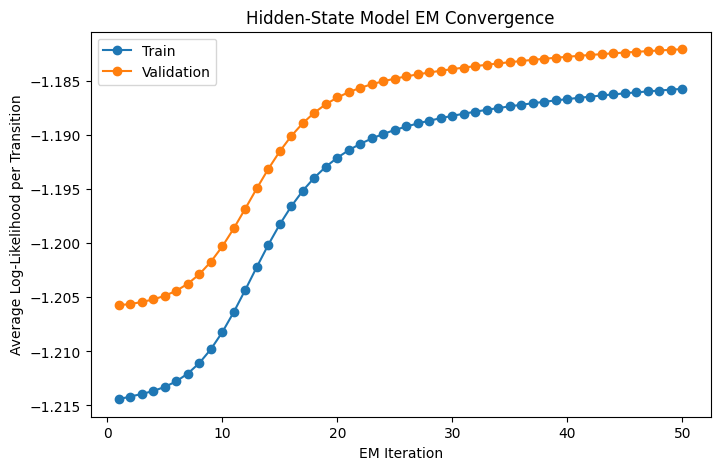

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_hidden["iteration"], history_hidden["train_avg_ll"], marker="o", label="Train")
plt.plot(history_hidden["iteration"], history_hidden["val_avg_ll"], marker="o", label="Validation")
plt.xlabel("EM Iteration")
plt.ylabel("Average Log-Likelihood per Transition")
plt.title("Hidden-State Model EM Convergence")
plt.legend()
plt.show()

In [ ]:
hidden_train_results = hidden_performance(train_sequences, pi_hidden, A_hidden, B_hidden)
hidden_val_results = hidden_performance(val_sequences, pi_hidden, A_hidden, B_hidden)
hidden_test_results = hidden_performance(test_sequences, pi_hidden, A_hidden, B_hidden)

print_baseline_results("HIDDEN MODEL TRAIN", hidden_train_results)
print_baseline_results("HIDDEN MODEL VALIDATION", hidden_val_results)
print_baseline_results("HIDDEN MODEL TEST", hidden_test_results)


HIDDEN MODEL TRAIN
Sequences:                7472
Transitions:              44992
Total log-likelihood:     -53348.11
Average log-likelihood per transition:  -1.185724
Perplexity:               3.273
Accuracy:                 0.6035

HIDDEN MODEL VALIDATION
Sequences:                1600
Transitions:              9707
Total log-likelihood:     -11474.29
Average log-likelihood per transition:  -1.182064
Perplexity:               3.261
Accuracy:                 0.6075

HIDDEN MODEL TEST
Sequences:                1600
Transitions:              9670
Total log-likelihood:     -11431.48
Average log-likelihood per transition:  -1.182159
Perplexity:               3.261
Accuracy:                 0.6055


The hidden-state DBN converged stably under EM and achieved better held-out performance than the baseline context-conditioned model. In particular, it improved validation and test log-likelihood, reduced perplexity, and increased predictive accuracy. This suggests that incorporating a latent regime variable helps capture temporal structure in morphology evolution beyond what is explained by the observed contextual variables alone.

# Section 5: Evaluation

We evaluated both the base model and the hidden-state model on the same test split, but broken down by solar cycle, morphology class, and context combination. We did this to see not just which model is better overall, but where the hidden-state model helps most and whether its gains are consistent across different parts of the data.

In [ ]:
def subset_sequence(sequence, mask):
    idx = np.where(mask)[0]
    if len(idx) == 0:
        return None

    return {
        "seq_id": sequence["seq_id"],
        "m_curr": sequence["m_curr"][idx],
        "m_next": sequence["m_next"][idx],
        "context": sequence["context"][idx],
        "length": len(idx),
        "steps": sequence["steps"][idx],
        "M_t_label": [sequence["M_t_label"][i] for i in idx],
        "M_t1_label": [sequence["M_t1_label"][i] for i in idx],
        "context_label": [sequence["context_label"][i] for i in idx],
        "date_t": [sequence["date_t"][i] for i in idx],
        "date_t1": [sequence["date_t1"][i] for i in idx],
    }

In [ ]:
def build_subset_sequences(sequences, keep_fn):
    subset_sequences = []

    for sequence in sequences:
        mask = np.array([keep_fn(sequence, t) for t in range(sequence["length"])], dtype=bool)
        sub_seq = subset_sequence(sequence, mask)

        if sub_seq is not None and sub_seq["length"] > 0:
            subset_sequences.append(sub_seq)

    return subset_sequences

In [ ]:
def evaluate_base_subset(sequences, probabilities):
    total_loglikelihood = 0.0
    total_transitions = 0
    total_correct = 0

    for sequence in sequences:
        m_curr = sequence["m_curr"]
        m_next = sequence["m_next"]
        context = sequence["context"]

        p = probabilities[context, m_curr, m_next]
        p = np.clip(p, 1e-10, None)

        total_loglikelihood += np.log(p).sum()
        total_transitions += sequence["length"]

        distribution_at_t = probabilities[context, m_curr, :]
        prediction = np.argmax(distribution_at_t, axis=1)
        total_correct += np.sum(prediction == m_next)

    if total_transitions == 0:
        return None

    return {
        "avg_ll": total_loglikelihood / total_transitions,
        "perplexity": np.exp(-total_loglikelihood / total_transitions),
        "accuracy": total_correct / total_transitions,
        "n_sequences": len(sequences),
        "n_transitions": total_transitions,
    }

In [ ]:
def evaluate_hidden_subset(sequences, pi, A, B):
    total_loglikelihood = 0.0
    total_transitions = 0
    total_correct = 0
    S_local = B.shape[2]
    K_local = B.shape[1]

    for sequence in sequences:
        alpha, scales, loglikelihood = forward_pass(sequence, pi, A, B)
        beta = backward_pass(sequence, A, B, scales)
        gamma, _ = compute_gamma_xi(sequence, alpha, beta, A, B)

        total_loglikelihood += loglikelihood
        total_transitions += sequence["length"]

        m_curr = sequence["m_curr"]
        preds = []

        for t in range(sequence["length"]):
            pred_dist = np.zeros(S_local, dtype=float)
            for z in range(K_local):
                pred_dist += gamma[t, z] * B[m_curr[t], z, :]
            preds.append(np.argmax(pred_dist))

        preds = np.array(preds)
        total_correct += np.sum(preds == sequence["m_next"])

    if total_transitions == 0:
        return None

    return {
        "avg_ll": total_loglikelihood / total_transitions,
        "perplexity": np.exp(-total_loglikelihood / total_transitions),
        "accuracy": total_correct / total_transitions,
        "n_sequences": len(sequences),
        "n_transitions": total_transitions,
    }

In [ ]:
def compare_models_on_groups(sequences, group_name, group_values, keep_fn, base_probabilities, pi, A, B):
    rows = []

    for value in group_values:
        subset_sequences = build_subset_sequences(
            sequences,
            keep_fn=lambda sequence, t, value=value: keep_fn(sequence, t, value)
        )

        base_results = evaluate_base_subset(subset_sequences, base_probabilities)
        hidden_results = evaluate_hidden_subset(subset_sequences, pi, A, B)

        if base_results is None or hidden_results is None:
            continue

        rows.append({
            group_name: value,
            "n_sequences": base_results["n_sequences"],
            "n_transitions": base_results["n_transitions"],
            "base_avg_ll": base_results["avg_ll"],
            "hidden_avg_ll": hidden_results["avg_ll"],
            "base_abs_avg_ll": abs(base_results["avg_ll"]),
            "hidden_abs_avg_ll": abs(hidden_results["avg_ll"]),
            "base_perplexity": base_results["perplexity"],
            "hidden_perplexity": hidden_results["perplexity"],
            "base_accuracy": base_results["accuracy"],
            "hidden_accuracy": hidden_results["accuracy"],
            "delta_avg_ll": hidden_results["avg_ll"] - base_results["avg_ll"],
            "delta_accuracy": hidden_results["accuracy"] - base_results["accuracy"],
            "delta_perplexity": hidden_results["perplexity"] - base_results["perplexity"],
        })

    df = pd.DataFrame(rows).sort_values("n_transitions", ascending=False).reset_index(drop=True)
    return df

In [ ]:
solar_cycles = sorted({
    context[2]
    for sequence in test_sequences
    for context in sequence["context_label"]
})

morphology_classes = sorted({
    label
    for sequence in test_sequences
    for label in sequence["M_t_label"]
})

context_combinations = sorted({
    context
    for sequence in test_sequences
    for context in sequence["context_label"]
})

cycle_results_df = compare_models_on_groups(
    sequences=test_sequences,
    group_name="solar_cycle",
    group_values=solar_cycles,
    keep_fn=lambda sequence, t, value: sequence["context_label"][t][2] == value,
    base_probabilities=base_probabilities,
    pi=pi_hidden,
    A=A_hidden,
    B=B_hidden
)

morphology_results_df = compare_models_on_groups(
    sequences=test_sequences,
    group_name="morphology_class",
    group_values=morphology_classes,
    keep_fn=lambda sequence, t, value: sequence["M_t_label"][t] == value,
    base_probabilities=base_probabilities,
    pi=pi_hidden,
    A=A_hidden,
    B=B_hidden
)

context_results_df = compare_models_on_groups(
    sequences=test_sequences,
    group_name="context_combination",
    group_values=context_combinations,
    keep_fn=lambda sequence, t, value: sequence["context_label"][t] == value,
    base_probabilities=base_probabilities,
    pi=pi_hidden,
    A=A_hidden,
    B=B_hidden
)

In [ ]:
print("Solar cycle evaluation")
display(cycle_results_df)

Solar cycle evaluation


,solar_cycle,n_sequences,n_transitions,base_avg_ll,hidden_avg_ll,base_abs_avg_ll,hidden_abs_avg_ll,base_perplexity,hidden_perplexity,base_accuracy,hidden_accuracy,delta_avg_ll,delta_accuracy,delta_perplexity
0,21,314,1923,-1.200302,-1.150572,1.200302,1.150572,3.321118,3.159998,0.600104,0.619865,0.049730,0.019761,-0.161120
1,22,290,1867,-1.115460,-1.090852,1.115460,1.090852,3.050973,2.976810,0.640064,0.643814,0.024608,0.003749,-0.074162
2,23,278,1707,-1.156938,-1.114262,1.156938,1.114262,3.180181,3.047317,0.618629,0.634446,0.042677,0.015817,-0.132864
3,20,280,1658,-1.158244,-1.134991,1.158244,1.134991,3.184338,3.111144,0.615199,0.623040,0.023254,0.007841,-0.073194
4,19,238,1468,-1.415960,-1.400627,1.415960,1.400627,4.120441,4.057745,0.503406,0.529973,0.015333,0.026567,-0.062696
5,24,144,759,-1.382692,-1.272910,1.382692,1.272910,3.985615,3.571228,0.504611,0.550725,0.109782,0.046113,-0.414387
6,25,57,288,-1.401740,-1.307381,1.401740,1.307381,4.062262,3.696479,0.534722,0.538194,0.094359,0.003472,-0.365783


In [ ]:
print("Morphology class evaluation")
display(morphology_results_df)

Morphology class evaluation


,morphology_class,n_sequences,n_transitions,base_avg_ll,hidden_avg_ll,base_abs_avg_ll,hidden_abs_avg_ll,base_perplexity,hidden_perplexity,base_accuracy,hidden_accuracy,delta_avg_ll,delta_accuracy,delta_perplexity
0,C,866,2151,-1.461424,-1.453749,1.461424,1.453749,4.312094,4.279127,0.499768,0.499768,0.007675,0.000000,-0.032967
1,J,563,1904,-1.012484,-0.977887,1.012484,0.977887,2.752428,2.658832,0.716387,0.715861,0.034597,-0.000525,-0.093596
2,D,633,1880,-1.147460,-1.152357,1.147460,1.152357,3.150183,3.165647,0.634574,0.637766,-0.004897,0.003191,0.015464
3,B,796,1583,-1.281155,-1.285052,1.281155,1.285052,3.600796,3.614856,0.492104,0.495894,-0.003897,0.003790,0.014059
4,A,658,1143,-1.159722,-1.132136,1.159722,1.132136,3.189045,3.102276,0.562555,0.664917,0.027585,0.102362,-0.086769
5,E,136,517,-1.124085,-1.080903,1.124085,1.080903,3.077398,2.947340,0.692456,0.719536,0.043181,0.027079,-0.130058
6,H,73,267,-1.188851,-0.991070,1.188851,0.991070,3.283308,2.694116,0.666667,0.722846,0.197781,0.056180,-0.589192
7,G,66,137,-1.614889,-1.547881,1.614889,1.547881,5.027331,4.701497,0.401460,0.496350,0.067008,0.094891,-0.325834
8,F,21,88,-1.316355,-1.028629,1.316355,1.028629,3.729800,2.797229,0.636364,0.818182,0.287725,0.181818,-0.932571


In [ ]:
print("Context combination evaluation")
display(context_results_df)

Context combination evaluation


,context_combination,n_sequences,n_transitions,base_avg_ll,hidden_avg_ll,base_abs_avg_ll,hidden_abs_avg_ll,base_perplexity,hidden_perplexity,base_accuracy,hidden_accuracy,delta_avg_ll,delta_accuracy,delta_perplexity
0,"(mid, N, 19)",108,690,-1.419353,-1.421536,1.419353,1.421536,4.134444,4.143479,0.511594,0.530435,-0.002183,0.018841,0.009035
1,"(mid, S, 22)",86,590,-0.996397,-0.995160,0.996397,0.995160,2.708507,2.705157,0.686441,0.689831,0.001237,0.003390,-0.003350
2,"(mid, N, 21)",88,569,-1.277635,-1.251390,1.277635,1.251390,3.588142,3.495198,0.576450,0.585237,0.026245,0.008787,-0.092945
3,"(mid, S, 23)",79,522,-1.112512,-1.093480,1.112512,1.093480,3.041992,2.984642,0.632184,0.637931,0.019033,0.005747,-0.057350
4,"(mid, S, 21)",80,488,-1.288001,-1.259945,1.288001,1.259945,3.625531,3.525227,0.569672,0.588115,0.028056,0.018443,-0.100303
5,"(mid, S, 19)",78,471,-1.405717,-1.389366,1.405717,1.389366,4.078450,4.012304,0.515924,0.530786,0.016351,0.014862,-0.066146
6,"(mid, S, 20)",75,430,-1.134631,-1.119744,1.134631,1.119744,3.110027,3.064069,0.625581,0.630233,0.014887,0.004651,-0.045957
7,"(mid, N, 20)",68,413,-1.198587,-1.178414,1.198587,1.178414,3.315429,3.249218,0.605327,0.612591,0.020173,0.007264,-0.066211
8,"(mid, N, 22)",65,409,-1.217910,-1.194472,1.217910,1.194472,3.380118,3.301814,0.601467,0.603912,0.023439,0.002445,-0.078304
9,"(early, N, 20)",63,383,-1.147515,-1.117491,1.147515,1.117491,3.150354,3.057173,0.629243,0.639687,0.030024,0.010444,-0.093182


In [ ]:
def plot_subset_comparison(df, group_col, metric_base, metric_hidden, title, rotate=False, top_n=None):
    plot_df = df.copy()

    if top_n is not None:
        plot_df = plot_df.head(top_n)

    x = np.arange(len(plot_df))
    width = 0.35

    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, plot_df[metric_base], width, label="Base")
    plt.bar(x + width / 2, plot_df[metric_hidden], width, label="Hidden")

    plt.xticks(
        x,
        [str(v) for v in plot_df[group_col]],
        rotation=45 if rotate else 0,
        ha="right" if rotate else "center"
    )

    plt.ylabel("Value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

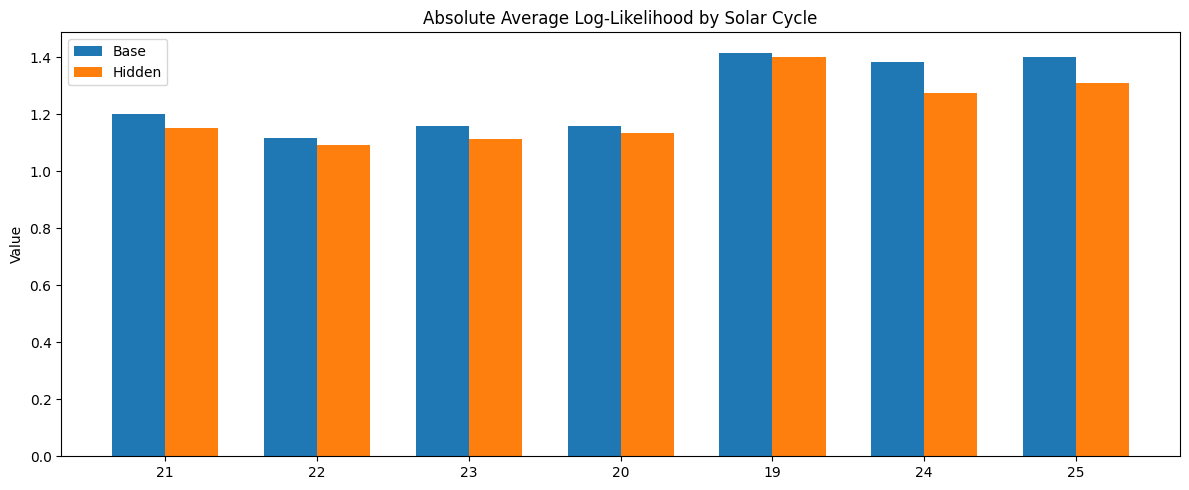

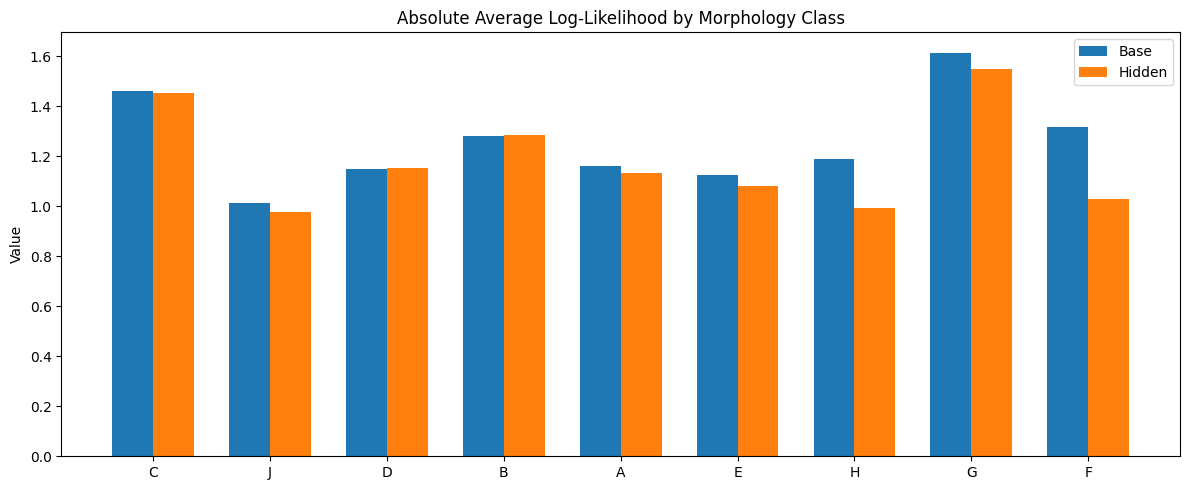

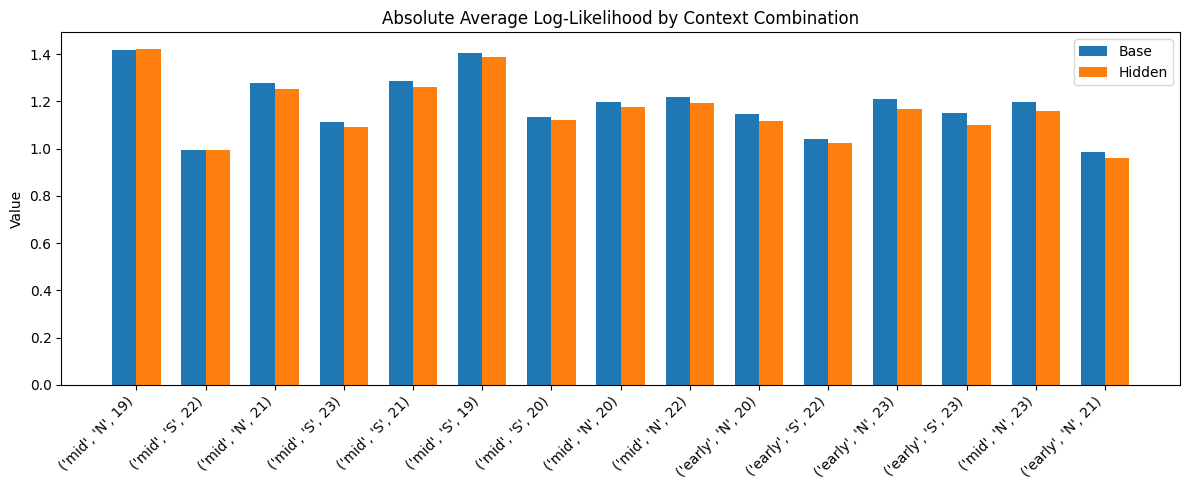

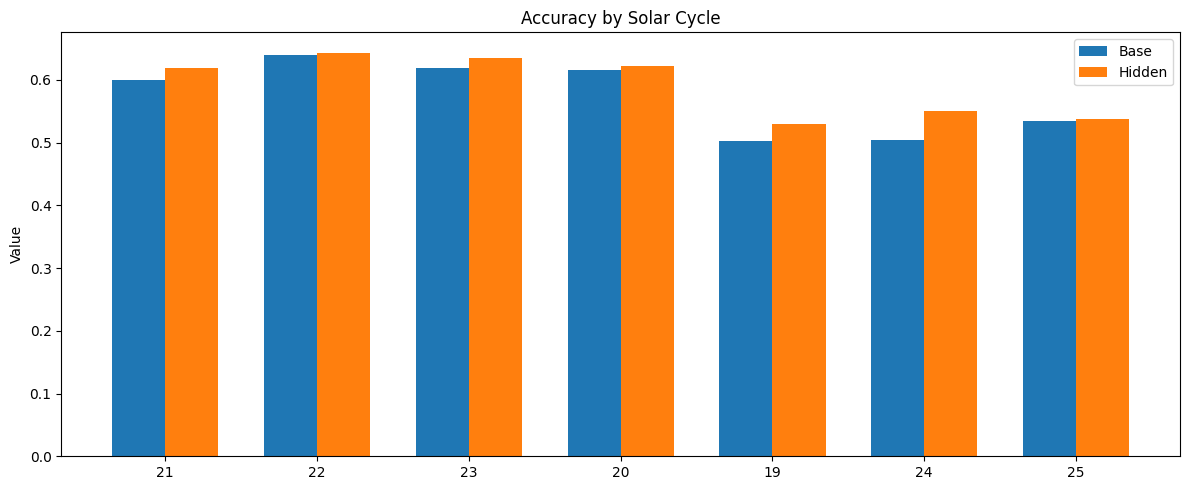

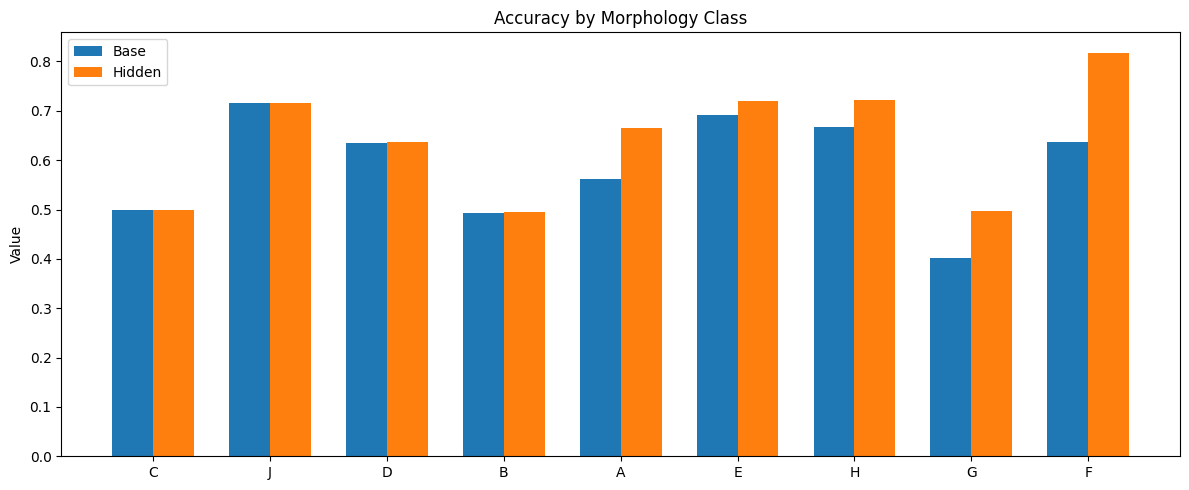

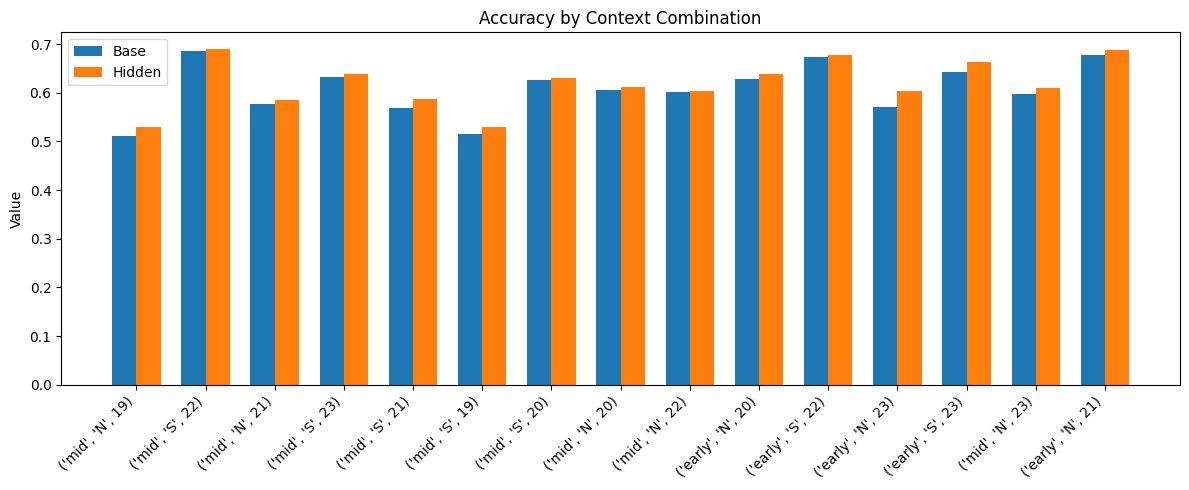

In [ ]:
plot_subset_comparison(
    cycle_results_df,
    group_col="solar_cycle",
    metric_base="base_abs_avg_ll",
    metric_hidden="hidden_abs_avg_ll",
    title="Absolute Average Log-Likelihood by Solar Cycle",
    rotate=False
)

plot_subset_comparison(
    morphology_results_df,
    group_col="morphology_class",
    metric_base="base_abs_avg_ll",
    metric_hidden="hidden_abs_avg_ll",
    title="Absolute Average Log-Likelihood by Morphology Class",
    rotate=False
)

plot_subset_comparison(
    context_results_df,
    group_col="context_combination",
    metric_base="base_abs_avg_ll",
    metric_hidden="hidden_abs_avg_ll",
    title="Absolute Average Log-Likelihood by Context Combination",
    rotate=True,
    top_n=15
)

#Accuracy plots
plot_subset_comparison(
    cycle_results_df,
    group_col="solar_cycle",
    metric_base="base_accuracy",
    metric_hidden="hidden_accuracy",
    title="Accuracy by Solar Cycle",
    rotate=False
)

plot_subset_comparison(
    morphology_results_df,
    group_col="morphology_class",
    metric_base="base_accuracy",
    metric_hidden="hidden_accuracy",
    title="Accuracy by Morphology Class",
    rotate=False
)

plot_subset_comparison(
    context_results_df,
    group_col="context_combination",
    metric_base="base_accuracy",
    metric_hidden="hidden_accuracy",
    title="Accuracy by Context Combination",
    rotate=True,
    top_n=15
)

We know that a lower absolute average log-likelihood means the actual average log-likelihood is less negative, so the hidden model is assigning higher probability to the transitions that really occurred. The hidden model consistently has values either equal or lower than that of the base model, which means it is matching the observed transitions at least as well, if not usually better.

This is the same story of the accuracy values, with a higher accuracy meaning that when each model makes its single best prediction for the next morphology, the hidden model is getting the correct class at least as often, and usually more often.

In [ ]:
base_train_results = base_performance(train_sequences, base_probabilities)
base_val_results = base_performance(val_sequences, base_probabilities)
base_test_results = base_performance(test_sequences, base_probabilities)

hidden_train_results = hidden_performance(train_sequences, pi_hidden, A_hidden, B_hidden)
hidden_val_results = hidden_performance(val_sequences, pi_hidden, A_hidden, B_hidden)
hidden_test_results = hidden_performance(test_sequences, pi_hidden, A_hidden, B_hidden)

In [ ]:
#Build one compact comparison table
import pandas as pd

comparison_rows = [
    {
        "split": "Train",
        "model": "Base",
        "avg_log_likelihood": base_train_results["average log-likelihood per transition"],
        "perplexity": base_train_results["perplexity"],
        "accuracy": base_train_results["accuracy"],
        "n_sequences": base_train_results["number of sequences"],
        "n_transitions": base_train_results["number of transitions"],
    },
    {
        "split": "Train",
        "model": "Hidden",
        "avg_log_likelihood": hidden_train_results["average log-likelihood per transition"],
        "perplexity": hidden_train_results["perplexity"],
        "accuracy": hidden_train_results["accuracy"],
        "n_sequences": hidden_train_results["number of sequences"],
        "n_transitions": hidden_train_results["number of transitions"],
    },
    {
        "split": "Validation",
        "model": "Base",
        "avg_log_likelihood": base_val_results["average log-likelihood per transition"],
        "perplexity": base_val_results["perplexity"],
        "accuracy": base_val_results["accuracy"],
        "n_sequences": base_val_results["number of sequences"],
        "n_transitions": base_val_results["number of transitions"],
    },
    {
        "split": "Validation",
        "model": "Hidden",
        "avg_log_likelihood": hidden_val_results["average log-likelihood per transition"],
        "perplexity": hidden_val_results["perplexity"],
        "accuracy": hidden_val_results["accuracy"],
        "n_sequences": hidden_val_results["number of sequences"],
        "n_transitions": hidden_val_results["number of transitions"],
    },
    {
        "split": "Test",
        "model": "Base",
        "avg_log_likelihood": base_test_results["average log-likelihood per transition"],
        "perplexity": base_test_results["perplexity"],
        "accuracy": base_test_results["accuracy"],
        "n_sequences": base_test_results["number of sequences"],
        "n_transitions": base_test_results["number of transitions"],
    },
    {
        "split": "Test",
        "model": "Hidden",
        "avg_log_likelihood": hidden_test_results["average log-likelihood per transition"],
        "perplexity": hidden_test_results["perplexity"],
        "accuracy": hidden_test_results["accuracy"],
        "n_sequences": hidden_test_results["number of sequences"],
        "n_transitions": hidden_test_results["number of transitions"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)

comparison_df["abs_avg_log_likelihood"] = comparison_df["avg_log_likelihood"].abs()

display(comparison_df)

,split,model,avg_log_likelihood,perplexity,accuracy,n_sequences,n_transitions,abs_avg_log_likelihood
0,Train,Base,-1.193848,3.299753,0.594417,7472,44992,1.193848
1,Train,Hidden,-1.185724,3.273057,0.603507,7472,44992,1.185724
2,Validation,Base,-1.224025,3.400850,0.592459,1600,9707,1.224025
3,Validation,Hidden,-1.182064,3.261098,0.607500,1600,9707,1.182064
4,Test,Base,-1.222110,3.394341,0.589555,1600,9670,1.222110
5,Test,Hidden,-1.182159,3.261409,0.605481,1600,9670,1.182159


In [ ]:
summary_table = comparison_df.pivot(
    index="split",
    columns="model",
    values=["avg_log_likelihood", "perplexity", "accuracy"]
)

display(summary_table)

avg_log_likelihood           perplexity            accuracy  \
model                    Base    Hidden       Base    Hidden      Base   
split                                                                    
Test                -1.222110 -1.182159   3.394341  3.261409  0.589555   
Train               -1.193848 -1.185724   3.299753  3.273057  0.594417   
Validation          -1.224025 -1.182064   3.400850  3.261098  0.592459   

                      
model         Hidden  
split                 
Test        0.605481  
Train       0.603507  
Validation  0.607500

# Section 6: Smoothing

Here we extend hidden-state model so that smoothing is no longer fixed at one shared value. Instead, we choose separate additive smoothing strengths/values for the three main parameter blocks, running a grid search over those choices, comparing them by validation, and outputting the best-smoothed model

In [ ]:
def initialize_hidden_model_with_smoothing(S, R, K, seed=1, smooth_pi=1.0, smooth_A=1.0, smooth_B=1.0):
    rng = np.random.default_rng(seed)

    pi = rng.random((R, K)) + smooth_pi
    pi = pi / pi.sum(axis=1, keepdims=True)

    A = rng.random((R, K, K)) + smooth_A
    A = A / A.sum(axis=2, keepdims=True)

    B = rng.random((S, K, S)) + smooth_B
    B = B / B.sum(axis=2, keepdims=True)

    return pi, A, B


def m_step_update_with_smoothing(pi_counts, A_counts, B_counts, smooth_pi=1.0, smooth_A=1.0, smooth_B=1.0):
    pi_new = pi_counts + smooth_pi
    pi_new = pi_new / pi_new.sum(axis=1, keepdims=True)

    A_new = A_counts + smooth_A
    A_new = A_new / A_new.sum(axis=2, keepdims=True)

    B_new = B_counts + smooth_B
    B_new = B_new / B_new.sum(axis=2, keepdims=True)

    return pi_new, A_new, B_new

In [ ]:
def em_iteration_with_smoothing(train_sequences, pi, A, B, R, S, K, smooth_pi=1.0, smooth_A=1.0, smooth_B=1.0):
    pi_counts, A_counts, B_counts, total_loglikelihood = expected_counts(
        train_sequences, pi, A, B, R, S, K
    )

    pi_new, A_new, B_new = m_step_update_with_smoothing(
        pi_counts,
        A_counts,
        B_counts,
        smooth_pi=smooth_pi,
        smooth_A=smooth_A,
        smooth_B=smooth_B
    )

    return pi_new, A_new, B_new, total_loglikelihood

In [ ]:
def fit_hidden_model_em_with_smoothing(
    train_sequences,
    val_sequences,
    S,
    R,
    K,
    smooth_pi=1.0,
    smooth_A=1.0,
    smooth_B=1.0,
    seed=1,
    max_iter=20,
    tol=1e-4
):
    pi, A, B = initialize_hidden_model_with_smoothing(
        S=S,
        R=R,
        K=K,
        seed=seed,
        smooth_pi=smooth_pi,
        smooth_A=smooth_A,
        smooth_B=smooth_B
    )

    history = []
    prev_val_ll = None

    for iteration in range(1, max_iter + 1):
        pi, A, B, train_ll_old = em_iteration_with_smoothing(
            train_sequences,
            pi,
            A,
            B,
            R,
            S,
            K,
            smooth_pi=smooth_pi,
            smooth_A=smooth_A,
            smooth_B=smooth_B
        )

        train_results = hidden_performance(train_sequences, pi, A, B)
        val_results = hidden_performance(val_sequences, pi, A, B)

        row = {
            "iteration": iteration,
            "train_ll": train_results["total log-likelihood"],
            "train_avg_ll": train_results["average log-likelihood per transition"],
            "train_perplexity": train_results["perplexity"],
            "train_accuracy": train_results["accuracy"],
            "val_ll": val_results["total log-likelihood"],
            "val_avg_ll": val_results["average log-likelihood per transition"],
            "val_perplexity": val_results["perplexity"],
            "val_accuracy": val_results["accuracy"],
        }
        history.append(row)

        if prev_val_ll is not None and abs(row["val_ll"] - prev_val_ll) < tol:
            break

        prev_val_ll = row["val_ll"]

    history = pd.DataFrame(history)
    return pi, A, B, history

In [ ]:
def tune_hidden_smoothing(
    train_sequences,
    val_sequences,
    S,
    R,
    K,
    smooth_pi_values,
    smooth_A_values,
    smooth_B_values,
    seed=1,
    max_iter=20,
    tol=1e-4
):
    results = []
    best_val_avg_ll = -np.inf
    best_model = None
    best_history = None

    for smooth_pi in smooth_pi_values:
        for smooth_A in smooth_A_values:
            for smooth_B in smooth_B_values:
                pi_fit, A_fit, B_fit, history = fit_hidden_model_em_with_smoothing(
                    train_sequences=train_sequences,
                    val_sequences=val_sequences,
                    S=S,
                    R=R,
                    K=K,
                    smooth_pi=smooth_pi,
                    smooth_A=smooth_A,
                    smooth_B=smooth_B,
                    seed=seed,
                    max_iter=max_iter,
                    tol=tol
                )

                train_results = hidden_performance(train_sequences, pi_fit, A_fit, B_fit)
                val_results = hidden_performance(val_sequences, pi_fit, A_fit, B_fit)

                row = {
                    "smooth_pi": smooth_pi,
                    "smooth_A": smooth_A,
                    "smooth_B": smooth_B,
                    "iterations_run": len(history),
                    "train_avg_ll": train_results["average log-likelihood per transition"],
                    "train_perplexity": train_results["perplexity"],
                    "train_accuracy": train_results["accuracy"],
                    "val_avg_ll": val_results["average log-likelihood per transition"],
                    "val_perplexity": val_results["perplexity"],
                    "val_accuracy": val_results["accuracy"],
                }
                results.append(row)

                if val_results["average log-likelihood per transition"] > best_val_avg_ll:
                    best_val_avg_ll = val_results["average log-likelihood per transition"]
                    best_model = (pi_fit, A_fit, B_fit)
                    best_history = history.copy()

    results_df = pd.DataFrame(results).sort_values(
        ["val_avg_ll", "val_accuracy"],
        ascending=[False, False]
    ).reset_index(drop=True)

    return best_model, best_history, results_df

In [ ]:
K = 2

smooth_pi_values = [0.1, 1.0, 2.0]
smooth_A_values = [0.1, 1.0, 2.0]
smooth_B_values = [0.1, 1.0, 2.0]

best_model, best_history, smoothing_results_df = tune_hidden_smoothing(
    train_sequences=train_sequences,
    val_sequences=val_sequences,
    S=S,
    R=R,
    K=K,
    smooth_pi_values=smooth_pi_values,
    smooth_A_values=smooth_A_values,
    smooth_B_values=smooth_B_values,
    seed=1,
    max_iter=20,
    tol=1e-4
)

pi_best, A_best, B_best = best_model

In [ ]:
display(smoothing_results_df)

,smooth_pi,smooth_A,smooth_B,iterations_run,train_avg_ll,train_perplexity,train_accuracy,val_avg_ll,val_perplexity,val_accuracy
0,1.0,1.0,0.1,20,-1.188809,3.283168,0.604863,-1.183907,3.267113,0.610487
1,2.0,1.0,0.1,20,-1.188824,3.283218,0.606152,-1.183939,3.267219,0.611105
2,1.0,2.0,0.1,20,-1.188919,3.283528,0.605752,-1.183961,3.267291,0.611105
3,0.1,1.0,0.1,20,-1.189069,3.284023,0.604574,-1.183963,3.267297,0.610281
4,2.0,2.0,0.1,20,-1.188936,3.283585,0.607019,-1.183991,3.267389,0.611414
5,0.1,2.0,0.1,20,-1.189178,3.284382,0.604574,-1.184031,3.267519,0.610384
6,1.0,0.1,0.1,20,-1.189797,3.286415,0.603152,-1.184882,3.270301,0.607706
7,2.0,0.1,0.1,20,-1.189812,3.286464,0.603174,-1.184952,3.270531,0.607706
8,0.1,0.1,0.1,20,-1.190189,3.287702,0.601907,-1.184960,3.270555,0.606367
9,1.0,2.0,1.0,20,-1.191899,3.293330,0.602507,-1.186333,3.275048,0.607191


In [ ]:
best_train_results = hidden_performance(train_sequences, pi_best, A_best, B_best)
best_val_results = hidden_performance(val_sequences, pi_best, A_best, B_best)
best_test_results = hidden_performance(test_sequences, pi_best, A_best, B_best)

print_baseline_results("BEST SMOOTHED HIDDEN MODEL TRAIN", best_train_results)
print_baseline_results("BEST SMOOTHED HIDDEN MODEL VALIDATION", best_val_results)
print_baseline_results("BEST SMOOTHED HIDDEN MODEL TEST", best_test_results)

print("\nBest smoothing setting:")
print(smoothing_results_df.iloc[0][["smooth_pi", "smooth_A", "smooth_B"]])


BEST SMOOTHED HIDDEN MODEL TRAIN
Sequences:                7472
Transitions:              44992
Total log-likelihood:     -53486.88
Average log-likelihood per transition:  -1.188809
Perplexity:               3.283
Accuracy:                 0.6049

BEST SMOOTHED HIDDEN MODEL VALIDATION
Sequences:                1600
Transitions:              9707
Total log-likelihood:     -11492.18
Average log-likelihood per transition:  -1.183907
Perplexity:               3.267
Accuracy:                 0.6105

BEST SMOOTHED HIDDEN MODEL TEST
Sequences:                1600
Transitions:              9670
Total log-likelihood:     -11446.03
Average log-likelihood per transition:  -1.183664
Perplexity:               3.266
Accuracy:                 0.6079

Best smoothing setting:
smooth_pi    1.0
smooth_A     1.0
smooth_B     0.1
Name: 0, dtype: float64


These results say the best version of the hidden-state model, among the smoothing choices you tested, uses smoothing 1.0 for the initial hidden-state distribution $\pi$, smoothing 1.0 for the hidden-state transition matrix $A$, and lighter smoothing 0.1 for the morphology transition table $B$.

Notice the average log-likelihood per transition is almost the same on validation and test, and the accuracies are also very close. That is a good sign, because it suggests the model is generalizing stably rather than overfitting badly to the training data.

# Section 7: Tuning Number of Hidden States

Using the optimal smoothing values found in Section 6, we now can train the hidden-state model for several values of $K$, and for each value of $K$ we randomly initialize the model using five different seeds. These random values initialize the initial hidden-state distribution, the hidden-state transition matrix, and the morphology transition table.

In [ ]:
def tune_hidden_states_K(
    train_sequences,
    val_sequences,
    S,
    R,
    K_values,
    seeds,
    smooth_pi=1.0,
    smooth_A=1.0,
    smooth_B=0.1,
    max_iter=20,
    tol=1e-4
):
    rows = []
    best_models_by_K = {}
    best_histories_by_K = {}

    for K in K_values:
        best_val_avg_ll_for_K = -np.inf
        best_model_for_K = None
        best_history_for_K = None

        for seed in seeds:
            pi_fit, A_fit, B_fit, history = fit_hidden_model_em_with_smoothing(
                train_sequences=train_sequences,
                val_sequences=val_sequences,
                S=S,
                R=R,
                K=K,
                smooth_pi=smooth_pi,
                smooth_A=smooth_A,
                smooth_B=smooth_B,
                seed=seed,
                max_iter=max_iter,
                tol=tol
            )

            train_results = hidden_performance(train_sequences, pi_fit, A_fit, B_fit)
            val_results = hidden_performance(val_sequences, pi_fit, A_fit, B_fit)

            row = {
                "K": K,
                "seed": seed,
                "iterations_run": len(history),
                "train_avg_ll": train_results["average log-likelihood per transition"],
                "train_perplexity": train_results["perplexity"],
                "train_accuracy": train_results["accuracy"],
                "val_avg_ll": val_results["average log-likelihood per transition"],
                "val_perplexity": val_results["perplexity"],
                "val_accuracy": val_results["accuracy"],
            }
            rows.append(row)

            if val_results["average log-likelihood per transition"] > best_val_avg_ll_for_K:
                best_val_avg_ll_for_K = val_results["average log-likelihood per transition"]
                best_model_for_K = (pi_fit, A_fit, B_fit)
                best_history_for_K = history.copy()

        best_models_by_K[K] = best_model_for_K
        best_histories_by_K[K] = best_history_for_K

    results_df = pd.DataFrame(rows)

    best_per_K_df = (
        results_df.sort_values(["K", "val_avg_ll", "val_accuracy"], ascending=[True, False, False])
        .groupby("K", as_index=False)
        .first()
        .sort_values("K")
        .reset_index(drop=True)
    )

    return results_df, best_per_K_df, best_models_by_K, best_histories_by_K

In [ ]:
K_values = [1, 2, 3, 4]
seeds = [1, 2, 3, 4, 5]

all_K_results_df, best_per_K_df, best_models_by_K, best_histories_by_K = tune_hidden_states_K(
    train_sequences=train_sequences,
    val_sequences=val_sequences,
    S=S,
    R=R,
    K_values=K_values,
    seeds=seeds,
    smooth_pi=1.0,
    smooth_A=1.0,
    smooth_B=0.1,
    max_iter=20,
    tol=1e-4
)

In [ ]:
test_rows = []

for K in K_values:
    pi_k, A_k, B_k = best_models_by_K[K]
    test_results = hidden_performance(test_sequences, pi_k, A_k, B_k)

    test_rows.append({
        "K": K,
        "test_avg_ll": test_results["average log-likelihood per transition"],
        "test_abs_avg_ll": abs(test_results["average log-likelihood per transition"]),
        "test_accuracy": test_results["accuracy"],
    })

K_test_df = pd.DataFrame(test_rows).sort_values("K").reset_index(drop=True)

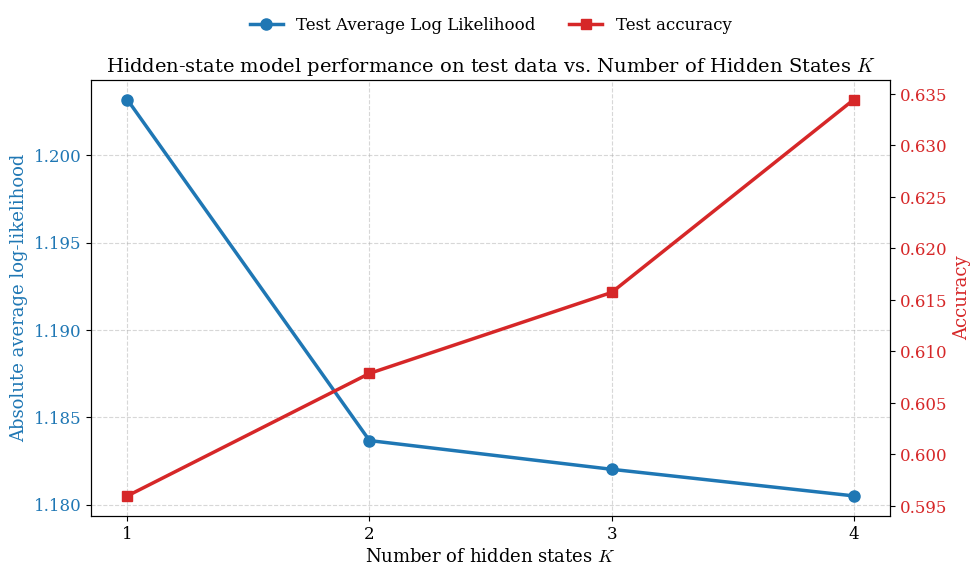

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": False,          # switch to True if your environment has LaTeX installed
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 13,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

x = np.arange(len(K_test_df))
k_labels = [str(k) for k in K_test_df["K"]]

fig, ax1 = plt.subplots(figsize=(10, 6))

line1 = ax1.plot(
    x,
    K_test_df["test_abs_avg_ll"],
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="tab:blue",
    label=r"Test Average Log Likelihood"
)
ax1.set_xlabel(r"Number of hidden states $K$")
ax1.set_ylabel(r"Absolute average log-likelihood", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_xticks(x)
ax1.set_xticklabels(k_labels)
ax1.grid(True, which="major", axis="both", linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
line2 = ax2.plot(
    x,
    K_test_df["test_accuracy"],
    marker="s",
    markersize=7,
    linewidth=2.5,
    color="tab:red",
    label=r"Test accuracy"
)
ax2.set_ylabel(r"Accuracy", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(
    lines,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.18),
    ncol=2,
    frameon=False
)

plt.title(r"Hidden-state model performance on test data vs. Number of Hidden States $K$")
plt.tight_layout()
plt.show()

# Section 8: Final Model

Using the results of the hyperparameters (number of hidden states), and the optimal smoothing values found in the previous section, we refit the model and evaluate its accuracy

In [ ]:
K_final = 4
smooth_pi_final = 1.0
smooth_A_final = 1.0
smooth_B_final = 0.1
final_seeds = [1, 2, 3, 4, 5]

In [ ]:
def fit_final_hidden_model(
    train_sequences,
    val_sequences,
    test_sequences,
    S,
    R,
    K,
    seeds,
    smooth_pi=1.0,
    smooth_A=1.0,
    smooth_B=0.1,
    max_iter=20,
    tol=1e-4
):
    best_val_avg_ll = -np.inf
    best_model = None

    for seed in seeds:
        pi_fit, A_fit, B_fit, history = fit_hidden_model_em_with_smoothing(
            train_sequences=train_sequences,
            val_sequences=val_sequences,
            S=S,
            R=R,
            K=K,
            smooth_pi=smooth_pi,
            smooth_A=smooth_A,
            smooth_B=smooth_B,
            seed=seed,
            max_iter=max_iter,
            tol=tol
        )

        val_results = hidden_performance(val_sequences, pi_fit, A_fit, B_fit)

        if val_results["average log-likelihood per transition"] > best_val_avg_ll:
            best_val_avg_ll = val_results["average log-likelihood per transition"]
            best_model = (pi_fit, A_fit, B_fit)

    pi_best, A_best, B_best = best_model
    test_results = hidden_performance(test_sequences, pi_best, A_best, B_best)

    return pi_best, A_best, B_best, test_results

In [ ]:
pi_final, A_final, B_final, final_test_results = fit_final_hidden_model(
    train_sequences=train_sequences,
    val_sequences=val_sequences,
    test_sequences=test_sequences,
    S=S,
    R=R,
    K=K_final,
    seeds=final_seeds,
    smooth_pi=smooth_pi_final,
    smooth_A=smooth_A_final,
    smooth_B=smooth_B_final,
    max_iter=20,
    tol=1e-4
)

In [ ]:
final_test_df = pd.DataFrame([{
    "K": K_final,
    "smooth_pi": smooth_pi_final,
    "smooth_A": smooth_A_final,
    "smooth_B": smooth_B_final,
    "test_accuracy": final_test_results["accuracy"],
    "test_avg_log_likelihood": final_test_results["average log-likelihood per transition"],
    "test_perplexity": final_test_results["perplexity"],
}])

display(final_test_df)

,K,smooth_pi,smooth_A,smooth_B,test_accuracy,test_avg_log_likelihood,test_perplexity
0,4,1.0,1.0,0.1,0.634436,-1.180495,3.255984


In [ ]:
final_comparison_df = pd.DataFrame([
    {
        "Model": "Baseline",
        "Accuracy": 0.5896,
        "Avg Log-Likelihood": -1.222110,
        "Perplexity": 3.394,
    },
    {
        "Model": "HMM",
        "Accuracy": 0.634436,
        "Avg Log-Likelihood": -1.180495,
        "Perplexity": 3.255984,
    }
])

display(
    final_comparison_df.style
    .format({
        "Accuracy": "{:.2%}",
        "Avg Log-Likelihood": "{:.4f}",
        "Perplexity": "{:.3f}",
    })
    .hide(axis="index")
)

Model,Accuracy,Avg Log-Likelihood,Perplexity
Baseline,58.96%,-1.2221,3.394
HMM,63.44%,-1.1805,3.256


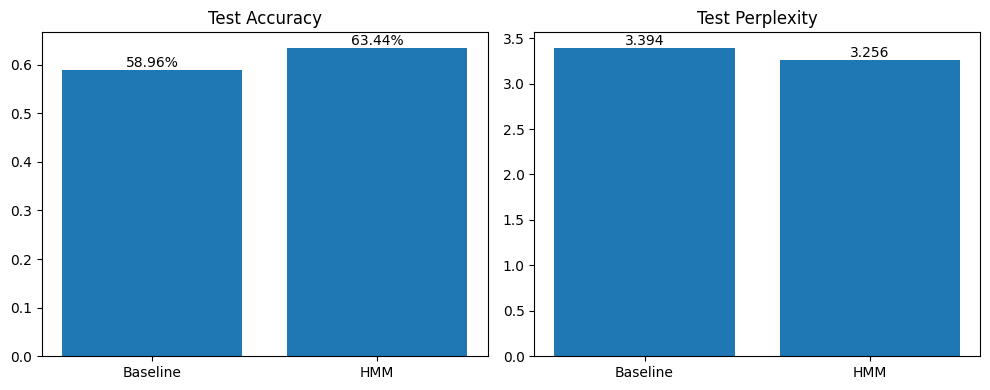

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(final_comparison_df["Model"], final_comparison_df["Accuracy"])
axes[0].set_title("Test Accuracy")

for i, v in enumerate(final_comparison_df["Accuracy"]):
    axes[0].text(i, v, f"{v:.2%}", ha="center", va="bottom")

axes[1].bar(final_comparison_df["Model"], final_comparison_df["Perplexity"])
axes[1].set_title("Test Perplexity")

for i, v in enumerate(final_comparison_df["Perplexity"]):
    axes[1].text(i, v, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()